In [ ]:
import yfinance as yf
import pandas as pd

etfs = {
    "Semiconductors & AI Chips": "SOXX",
    "Cloud & Data Centers": "SKYY",
    "Robotics & Automation": "BOTZ",
    "Healthcare AI": "ARKG",
    "Broad AI": "AIQ"
}

results = []

for subsector, ticker in etfs.items():
    etf = yf.Ticker(ticker)
    history = etf.history(period="3y")

    # debug: print how many rows we got
    print(f"{ticker}: {len(history)} rows of data")
    print(history.tail(3))
    print("---")

SOXX: 753 rows of data
                                 Open        High         Low      Close  \
Date                                                                       
2026-06-16 00:00:00-04:00  623.840027  629.640015  590.630005  591.23999   
2026-06-17 00:00:00-04:00  611.559998  621.989990  598.950012  599.72998   
2026-06-18 00:00:00-04:00         NaN         NaN         NaN        NaN   

                             Volume  Dividends  Stock Splits  Capital Gains  
Date                                                                         
2026-06-16 00:00:00-04:00  11204900        0.0           0.0            0.0  
2026-06-17 00:00:00-04:00   8948400        0.0           0.0            0.0  
2026-06-18 00:00:00-04:00   9499491        0.0           0.0            0.0  
---
SKYY: 753 rows of data
                                 Open        High         Low       Close  \
Date                                                                        
2026-06-16 00:00:00-04:00

In [ ]:
import yfinance as yf
import pandas as pd

etfs = {
    "Semiconductors & AI Chips": "SOXX",
    "Cloud & Data Centers": "SKYY",
    "Robotics & Automation": "BOTZ",
    "Healthcare AI": "ARKG",
    "Broad AI": "AIQ"
}

results = []

for subsector, ticker in etfs.items():
    etf = yf.Ticker(ticker)
    history = etf.history(period="3y")

    # drop any rows where Close is NaN
    history = history.dropna(subset=["Close"])

    import datetime

    one_year_ago = (datetime.date.today() - datetime.timedelta(days=365)).strftime('%Y-%m-%d')

    price_start_1y = history.loc[history.index >= one_year_ago, "Close"].iloc[0]
    price_start_3y = history["Close"].iloc[0]
    price_now = history["Close"].iloc[-1]

    # calculate returns
    return_1y = round(((price_now - price_start_1y) / price_start_1y) * 100, 2)
    return_3y = round(((price_now - price_start_3y) / price_start_3y) * 100, 2)

    results.append({
        "Sub-sector": subsector,
        "ETF": ticker,
        "1 Year Return (%)": return_1y,
        "3 Year Return (%)": return_3y
    })

etf_df = pd.DataFrame(results)
etf_df.sort_values("1 Year Return (%)", ascending=False)

,Sub-sector,ETF,1 Year Return (%),3 Year Return (%)
0,Semiconductors & AI Chips,SOXX,167.66,264.62
4,Broad AI,AIQ,55.32,130.12
3,Healthcare AI,ARKG,47.23,0.89
2,Robotics & Automation,BOTZ,24.29,29.69
1,Cloud & Data Centers,SKYY,14.96,73.35


In [ ]:
import yfinance as yf
import pandas as pd

# all current SOXX holdings as of June 2026
all_tickers = [
    "MU", "AMD", "AVGO", "INTC", "MRVL",
    "NVDA", "AMAT", "QCOM", "TXN", "NXPI",
    "LRCX", "KLAC", "SNPS", "CDNS", "ADI",
    "MCHP", "ON", "WOLF", "SWKS", "QRVO",
    "TER", "MPWR", "ACLS", "FORM", "SITM",
    "DIOD", "SMCI", "ONTO", "COHU", "LSCC",
    "AMBA", "CRUS", "POWI", "SNDK"
]

print(f"Total companies to screen: {len(all_tickers)}")

Total companies to screen: 34


In [ ]:
results = []

for ticker in all_tickers:
    try:
        stock = yf.Ticker(ticker)
        info = stock.info

        name = info.get("longName", ticker)
        pe = info.get("trailingPE")
        forward_pe = info.get("forwardPE")
        roe = info.get("returnOnEquity")
        rev_growth = info.get("revenueGrowth")
        profit_margin = info.get("profitMargins")

        results.append({
            "Ticker": ticker,
            "Company": name,
            "P/E Ratio": round(pe, 2) if pe else None,
            "Forward P/E": round(forward_pe, 2) if forward_pe else None,
            "ROE (%)": round(roe * 100, 2) if roe else None,
            "Revenue Growth (%)": round(rev_growth * 100, 2) if rev_growth else None,
            "Profit Margin (%)": round(profit_margin * 100, 2) if profit_margin else None
        })

        print(f"✓ {ticker} done")

    except Exception as e:
        print(f"✗ {ticker} failed: {e}")

fundamentals_df = pd.DataFrame(results)
fundamentals_df

✓ MU done
✓ AMD done
✓ AVGO done
✓ INTC done
✓ MRVL done
✓ NVDA done
✓ AMAT done
✓ QCOM done
✓ TXN done
✓ NXPI done
✓ LRCX done
✓ KLAC done
✓ SNPS done
✓ CDNS done
✓ ADI done
✓ MCHP done
✓ ON done
✓ WOLF done
✓ SWKS done
✓ QRVO done
✓ TER done
✓ MPWR done
✓ ACLS done
✓ FORM done
✓ SITM done
✓ DIOD done
✓ SMCI done
✓ ONTO done
✓ COHU done
✓ LSCC done
✓ AMBA done
✓ CRUS done
✓ POWI done
✓ SNDK done


,Ticker,Company,P/E Ratio,Forward P/E,ROE (%),Revenue Growth (%),Profit Margin (%)
0,MU,"Micron Technology, Inc.",53.41,9.90,39.82,196.3,41.49
1,AMD,"Advanced Micro Devices, Inc.",179.72,41.01,8.06,37.8,13.37
2,AVGO,Broadcom Inc.,68.22,21.26,37.28,47.9,38.85
3,INTC,Intel Corporation,NaN,86.70,-2.91,7.2,-5.90
4,MRVL,"Marvell Technology, Inc.",107.10,50.32,16.03,27.6,28.99
5,NVDA,NVIDIA Corporation,32.26,16.55,114.29,85.2,62.97
6,AMAT,"Applied Materials, Inc.",58.05,37.95,39.69,11.4,29.31
7,QCOM,QUALCOMM Incorporated,24.34,21.20,36.08,-3.5,22.31
8,TXN,Texas Instruments Incorporated,55.28,34.27,32.35,18.6,29.11
9,NXPI,NXP Semiconductors N.V.,29.98,17.77,25.81,12.2,21.03


In [ ]:
import yfinance as yf
import pandas as pd

# redefine all tickers
all_tickers = [
    "MU", "AMD", "AVGO", "INTC", "MRVL",
    "NVDA", "AMAT", "QCOM", "TXN", "NXPI",
    "LRCX", "KLAC", "SNPS", "CDNS", "ADI",
    "MCHP", "ON", "WOLF", "SWKS", "QRVO",
    "TER", "MPWR", "ACLS", "FORM", "SITM",
    "DIOD", "SMCI", "ONTO", "COHU", "LSCC",
    "AMBA", "CRUS", "POWI", "SNDK"
]

# rerun fundamentals fetch
results = []

for ticker in all_tickers:
    try:
        stock = yf.Ticker(ticker)
        info = stock.info

        name = info.get("longName", ticker)
        pe = info.get("trailingPE")
        forward_pe = info.get("forwardPE")
        roe = info.get("returnOnEquity")
        rev_growth = info.get("revenueGrowth")
        profit_margin = info.get("profitMargins")
        ev_ebitda = info.get("enterpriseToEbitda")
        peg = info.get("trailingPegRatio")
        debt_equity = info.get("debtToEquity")

        results.append({
            "Ticker": ticker,
            "Company": name,
            "P/E Ratio": round(pe, 2) if pe else None,
            "Forward P/E": round(forward_pe, 2) if forward_pe else None,
            "ROE (%)": round(roe * 100, 2) if roe else None,
            "Revenue Growth (%)": round(rev_growth * 100, 2) if rev_growth else None,
            "Profit Margin (%)": round(profit_margin * 100, 2) if profit_margin else None,
            "EV/EBITDA": round(ev_ebitda, 2) if ev_ebitda else None,
            "PEG Ratio": round(peg, 2) if peg else None,
            "Debt to Equity": round(debt_equity, 2) if debt_equity else None
        })

        print(f"✓ {ticker} done")

    except Exception as e:
        print(f"✗ {ticker} failed: {e}")

full_df = pd.DataFrame(results)
full_df

✓ MU done
✓ AMD done
✓ AVGO done
✓ INTC done
✓ MRVL done
✓ NVDA done
✓ AMAT done
✓ QCOM done
✓ TXN done
✓ NXPI done
✓ LRCX done
✓ KLAC done
✓ SNPS done
✓ CDNS done
✓ ADI done
✓ MCHP done
✓ ON done
✓ WOLF done
✓ SWKS done
✓ QRVO done
✓ TER done
✓ MPWR done
✓ ACLS done
✓ FORM done
✓ SITM done
✓ DIOD done
✓ SMCI done
✓ ONTO done
✓ COHU done
✓ LSCC done
✓ AMBA done
✓ CRUS done
✓ POWI done
✓ SNDK done


,Ticker,Company,P/E Ratio,Forward P/E,ROE (%),Revenue Growth (%),Profit Margin (%),EV/EBITDA,PEG Ratio,Debt to Equity
0,MU,"Micron Technology, Inc.",53.41,9.90,39.82,196.3,41.49,31.18,0.36,14.90
1,AMD,"Advanced Micro Devices, Inc.",179.72,41.01,8.06,37.8,13.37,110.19,1.29,6.00
2,AVGO,Broadcom Inc.,68.22,21.26,37.28,47.9,38.85,43.66,0.75,74.02
3,INTC,Intel Corporation,NaN,86.70,-2.91,7.2,-5.90,43.33,NaN,36.03
4,MRVL,"Marvell Technology, Inc.",107.10,50.32,16.03,27.6,28.99,90.42,1.76,28.97
5,NVDA,NVIDIA Corporation,32.26,16.55,114.29,85.2,62.97,30.08,0.65,6.55
6,AMAT,"Applied Materials, Inc.",58.05,37.95,39.69,11.4,29.31,48.54,2.05,30.40
7,QCOM,QUALCOMM Incorporated,24.34,21.20,36.08,-3.5,22.31,17.78,0.96,55.98
8,TXN,Texas Instruments Incorporated,55.28,34.27,32.35,18.6,29.11,33.14,1.54,83.74
9,NXPI,NXP Semiconductors N.V.,29.98,17.77,25.81,12.2,21.03,20.39,0.80,103.99


In [ ]:
# remove companies with negative metrics
filtered_df = full_df[
    (full_df["ROE (%)"] > 0) &
    (full_df["Revenue Growth (%)"] > 0) &
    (full_df["Profit Margin (%)"] > 0) &
    (full_df["EV/EBITDA"] > 0) &
    (full_df["Debt to Equity"] > 0)
].reset_index(drop=True)

print(f"Companies remaining after removing negatives: {len(filtered_df)}")
filtered_df

Companies remaining after removing negatives: 24


,Ticker,Company,P/E Ratio,Forward P/E,ROE (%),Revenue Growth (%),Profit Margin (%),EV/EBITDA,PEG Ratio,Debt to Equity
0,MU,"Micron Technology, Inc.",53.41,9.90,39.82,196.3,41.49,31.18,0.36,14.90
1,AMD,"Advanced Micro Devices, Inc.",179.72,41.01,8.06,37.8,13.37,110.19,1.29,6.00
2,AVGO,Broadcom Inc.,68.22,21.26,37.28,47.9,38.85,43.66,0.75,74.02
3,MRVL,"Marvell Technology, Inc.",107.10,50.32,16.03,27.6,28.99,90.42,1.76,28.97
4,NVDA,NVIDIA Corporation,32.26,16.55,114.29,85.2,62.97,30.08,0.65,6.55
5,AMAT,"Applied Materials, Inc.",58.05,37.95,39.69,11.4,29.31,48.54,2.05,30.40
6,TXN,Texas Instruments Incorporated,55.28,34.27,32.35,18.6,29.11,33.14,1.54,83.74
7,NXPI,NXP Semiconductors N.V.,29.98,17.77,25.81,12.2,21.03,20.39,0.80,103.99
8,LRCX,Lam Research Corporation,73.68,48.78,66.76,23.8,30.94,58.73,2.26,35.28
9,KLAC,KLA Corporation,73.32,51.42,94.98,11.5,35.66,53.20,2.68,105.40


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

# all 34 SOXX tickers
all_tickers = [
    "MU", "AMD", "AVGO", "INTC", "MRVL",
    "NVDA", "AMAT", "QCOM", "TXN", "NXPI",
    "LRCX", "KLAC", "SNPS", "CDNS", "ADI",
    "MCHP", "ON", "WOLF", "SWKS", "QRVO",
    "TER", "MPWR", "ACLS", "FORM", "SITM",
    "DIOD", "SMCI", "ONTO", "COHU", "LSCC",
    "AMBA", "CRUS", "POWI", "SNDK"
]

# rebuild fundamentals
results = []
for ticker in all_tickers:
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        pe = info.get("trailingPE")
        forward_pe = info.get("forwardPE")
        roe = info.get("returnOnEquity")
        rev_growth = info.get("revenueGrowth")
        profit_margin = info.get("profitMargins")
        ev_ebitda = info.get("enterpriseToEbitda")
        peg = info.get("trailingPegRatio")
        debt_equity = info.get("debtToEquity")
        results.append({
            "Ticker": ticker,
            "Company": info.get("longName", ticker),
            "P/E Ratio": round(pe, 2) if pe else None,
            "Forward P/E": round(forward_pe, 2) if forward_pe else None,
            "ROE (%)": round(roe * 100, 2) if roe else None,
            "Revenue Growth (%)": round(rev_growth * 100, 2) if rev_growth else None,
            "Profit Margin (%)": round(profit_margin * 100, 2) if profit_margin else None,
            "EV/EBITDA": round(ev_ebitda, 2) if ev_ebitda else None,
            "PEG Ratio": round(peg, 2) if peg else None,
            "Debt to Equity": round(debt_equity, 2) if debt_equity else None
        })
        print(f"✓ {ticker}")
    except Exception as e:
        print(f"✗ {ticker}: {e}")

full_df = pd.DataFrame(results)

# stage 1 filter - remove negatives
filtered_df = full_df[
    (full_df["ROE (%)"] > 0) &
    (full_df["Revenue Growth (%)"] > 0) &
    (full_df["Profit Margin (%)"] > 0) &
    (full_df["EV/EBITDA"] > 0) &
    (full_df["Debt to Equity"] > 0)
].reset_index(drop=True)

# stage 2 filter - apply thresholds
screened_df = filtered_df[
    (filtered_df["P/E Ratio"] < 150) &
    (filtered_df["Forward P/E"] < 45) &
    (filtered_df["ROE (%)"] > 15) &
    (filtered_df["Revenue Growth (%)"] > 10) &
    (filtered_df["Profit Margin (%)"] > 10) &
    (filtered_df["EV/EBITDA"] < 60) &
    (filtered_df["Debt to Equity"] < 110) &
    ((filtered_df["PEG Ratio"] < 3) | (filtered_df["PEG Ratio"].isna()))
].reset_index(drop=True)

# final 5 companies
final_companies = ["NVDA", "MU", "AVGO", "LRCX", "SNDK"]
final_df = screened_df[screened_df["Ticker"].isin(final_companies)].reset_index(drop=True)

print(f"\n✓ full_df: {len(full_df)} companies")
print(f"✓ filtered_df: {len(filtered_df)} companies after stage 1")
print(f"✓ screened_df: {len(screened_df)} companies after stage 2")
print(f"✓ final_df: {len(final_df)} final companies")
print("\nAll variables rebuilt successfully")

✓ MU
✓ AMD
✓ AVGO
✓ INTC
✓ MRVL
✓ NVDA
✓ AMAT
✓ QCOM
✓ TXN
✓ NXPI
✓ LRCX
✓ KLAC
✓ SNPS
✓ CDNS
✓ ADI
✓ MCHP
✓ ON
✓ WOLF
✓ SWKS
✓ QRVO
✓ TER
✓ MPWR
✓ ACLS
✓ FORM
✓ SITM
✓ DIOD
✓ SMCI
✓ ONTO
✓ COHU
✓ LSCC
✓ AMBA
✓ CRUS
✓ POWI
✓ SNDK

✓ full_df: 34 companies
✓ filtered_df: 24 companies after stage 1
✓ screened_df: 7 companies after stage 2
✓ final_df: 4 final companies

All variables rebuilt successfully


In [ ]:
screened_df = filtered_df[
    (filtered_df["P/E Ratio"] < 150) &
    (filtered_df["Forward P/E"] < 45) &
    (filtered_df["ROE (%)"] > 15) &
    (filtered_df["Revenue Growth (%)"] > 10) &
    (filtered_df["Profit Margin (%)"] > 10) &
    (filtered_df["EV/EBITDA"] < 60) &
    (filtered_df["Debt to Equity"] < 110) &
    ((filtered_df["PEG Ratio"] < 3) | (filtered_df["PEG Ratio"].isna()))
].reset_index(drop=True)

print(f"Companies passing all filters: {len(screened_df)}")
screened_df

Companies passing all filters: 7


,Ticker,Company,P/E Ratio,Forward P/E,ROE (%),Revenue Growth (%),Profit Margin (%),EV/EBITDA,PEG Ratio,Debt to Equity
0,MU,"Micron Technology, Inc.",53.41,9.90,39.82,196.3,41.49,31.18,0.36,14.90
1,AVGO,Broadcom Inc.,68.22,21.26,37.28,47.9,38.85,43.66,0.75,74.02
2,NVDA,NVIDIA Corporation,32.26,16.55,114.29,85.2,62.97,30.08,0.65,6.55
3,AMAT,"Applied Materials, Inc.",58.05,37.95,39.69,11.4,29.31,48.54,2.05,30.40
4,TXN,Texas Instruments Incorporated,55.28,34.27,32.35,18.6,29.11,33.14,1.54,83.74
5,NXPI,NXP Semiconductors N.V.,29.98,17.77,25.81,12.2,21.03,20.39,0.80,103.99
6,SNDK,Sandisk Corporation,74.62,11.94,39.30,251.0,34.19,51.74,NaN,1.50


In [ ]:
# sector benchmark - average metrics across all 34 SOXX holdings
benchmark_data = []

for ticker in all_tickers:
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        pe = info.get("trailingPE")
        forward_pe = info.get("forwardPE")
        ev_ebitda = info.get("enterpriseToEbitda")
        peg = info.get("trailingPegRatio")
        roe = info.get("returnOnEquity")
        rev_growth = info.get("revenueGrowth")
        profit_margin = info.get("profitMargins")
        debt_equity = info.get("debtToEquity")

        benchmark_data.append({
            "Ticker": ticker,
            "P/E": pe,
            "Forward P/E": forward_pe,
            "EV/EBITDA": ev_ebitda,
            "PEG": peg,
            "ROE (%)": round(roe * 100, 2) if roe else None,
            "Revenue Growth (%)": round(rev_growth * 100, 2) if rev_growth else None,
            "Profit Margin (%)": round(profit_margin * 100, 2) if profit_margin else None,
            "Debt to Equity": debt_equity
        })
        print(f"✓ {ticker}")

    except Exception as e:
        print(f"✗ {ticker}: {e}")

benchmark_df = pd.DataFrame(benchmark_data)

# metrics and thresholds
metrics = {
    "P/E": "< 150",
    "Forward P/E": "< 45",
    "EV/EBITDA": "< 60",
    "PEG": "< 3",
    "ROE (%)": "> 15%",
    "Revenue Growth (%)": "> 10%",
    "Profit Margin (%)": "> 10%",
    "Debt to Equity": "< 110"
}

rows = []
for metric, threshold in metrics.items():
    clean = benchmark_df[metric].dropna()
    clean = clean[clean > 0]
    rows.append({
        "Metric": metric,
        "Sector Mean": round(clean.mean(), 2),
        "Sector Median": round(clean.median(), 2),
        "Min": round(clean.min(), 2),
        "Max": round(clean.max(), 2),
        "Our Threshold": threshold,
        "Companies with Data": len(clean)
    })

benchmark_summary = pd.DataFrame(rows).set_index("Metric")
print("\nSOXX Sector Benchmark — All 34 Holdings (Yahoo Finance, June 2026):")
benchmark_summary

✓ MU
✓ AMD
✓ AVGO
✓ INTC
✓ MRVL
✓ NVDA
✓ AMAT
✓ QCOM
✓ TXN
✓ NXPI
✓ LRCX
✓ KLAC
✓ SNPS
✓ CDNS
✓ ADI
✓ MCHP
✓ ON
✓ WOLF
✓ SWKS
✓ QRVO
✓ TER
✓ MPWR
✓ ACLS
✓ FORM
✓ SITM
✓ DIOD
✓ SMCI
✓ ONTO
✓ COHU
✓ LSCC
✓ AMBA
✓ CRUS
✓ POWI
✓ SNDK

SOXX Sector Benchmark — All 34 Holdings (Yahoo Finance, June 2026):


,Sector Mean,Sector Median,Min,Max,Our Threshold,Companies with Data
Metric,,,,,,
P/E,129.94,73.32,16.14,1098.00,< 150,29
Forward P/E,36.13,34.27,9.67,86.70,< 45,33
EV/EBITDA,228.49,47.52,10.92,5477.49,< 60,31
PEG,1.49,1.54,0.36,3.68,< 3,21
ROE (%),25.16,17.88,2.36,114.29,> 15%,29
Revenue Growth (%),45.19,26.85,2.60,251.00,> 10%,30
Profit Margin (%),20.34,21.03,3.46,62.97,> 10%,29
Debt to Equity,39.60,29.68,0.26,179.16,< 110,32


In [ ]:
# final 5 companies selected for portfolio
final_companies = ["NVDA", "MU", "AVGO", "LRCX", "SNDK"]

final_df = screened_df[screened_df["Ticker"].isin(final_companies)].reset_index(drop=True)

print("Final portfolio candidates:")
final_df

Final portfolio candidates:


,Ticker,Company,P/E Ratio,Forward P/E,ROE (%),Revenue Growth (%),Profit Margin (%),EV/EBITDA,PEG Ratio,Debt to Equity
0,MU,"Micron Technology, Inc.",53.41,9.90,39.82,196.3,41.49,31.18,0.36,14.90
1,AVGO,Broadcom Inc.,68.22,21.26,37.28,47.9,38.85,43.66,0.75,74.02
2,NVDA,NVIDIA Corporation,32.26,16.55,114.29,85.2,62.97,30.08,0.65,6.55
3,SNDK,Sandisk Corporation,74.62,11.94,39.30,251.0,34.19,51.74,NaN,1.50


In [ ]:
# valuation benchmarks
SECTOR_PE = 66.24          # semiconductor sector average P/E
SECTOR_FORWARD_PE = 30.0   # estimated sector forward P/E
SECTOR_EV_EBITDA = 27.0    # semiconductor sector average EV/EBITDA
PEG_UNDERVALUED = 1.0      # universal PEG benchmark
PEG_OVERVALUED = 2.0       # universal PEG benchmark

def pe_verdict(pe, benchmark):
    if pe is None or pd.isna(pe):
        return "No Data"
    elif pe < benchmark * 0.85:
        return "Undervalued"
    elif pe > benchmark * 1.15:
        return "Overvalued"
    else:
        return "Fairly Valued"

def peg_verdict(peg):
    if peg is None or pd.isna(peg):
        return "No Data"
    elif peg < 1.0:
        return "Undervalued"
    elif peg > 2.0:
        return "Overvalued"
    else:
        return "Fairly Valued"

def forward_pe_verdict(trailing_pe, forward_pe):
    if trailing_pe is None or forward_pe is None:
        return "No Data"
    if pd.isna(trailing_pe) or pd.isna(forward_pe):
        return "No Data"
    gap = trailing_pe - forward_pe
    gap_pct = (gap / trailing_pe) * 100
    if gap_pct > 40:
        return "Undervalued"
    elif gap_pct < 15:
        return "Overvalued"
    else:
        return "Fairly Valued"

def final_verdict(v1, v2, v3):
    verdicts = [v for v in [v1, v2, v3] if v != "No Data"]
    if not verdicts:
        return "Insufficient Data"
    undervalued = verdicts.count("Undervalued")
    overvalued = verdicts.count("Overvalued")
    if undervalued >= 2:
        return "UNDERVALUED"
    elif overvalued >= 2:
        return "OVERVALUED"
    else:
        return "FAIRLY VALUED"

# build valuation table
valuation_rows = []

for _, row in final_df.iterrows():
    v1 = pe_verdict(row["P/E Ratio"], SECTOR_PE)
    v2 = peg_verdict(row["PEG Ratio"])
    v3 = forward_pe_verdict(row["P/E Ratio"], row["Forward P/E"])
    verdict = final_verdict(v1, v2, v3)

    valuation_rows.append({
        "Ticker": row["Ticker"],
        "Company": row["Company"],
        "P/E vs Sector (66)": v1,
        "PEG Assessment": v2,
        "Forward vs Trailing P/E": v3,
        "Final Verdict": verdict
    })

valuation_df = pd.DataFrame(valuation_rows)
valuation_df

,Ticker,Company,P/E vs Sector (66),PEG Assessment,Forward vs Trailing P/E,Final Verdict
0,MU,"Micron Technology, Inc.",Undervalued,Undervalued,Undervalued,UNDERVALUED
1,AVGO,Broadcom Inc.,Fairly Valued,Undervalued,Undervalued,UNDERVALUED
2,NVDA,NVIDIA Corporation,Undervalued,Undervalued,Undervalued,UNDERVALUED
3,SNDK,Sandisk Corporation,Fairly Valued,No Data,Undervalued,FAIRLY VALUED


In [ ]:
print(final_df["Ticker"].tolist())

['MU', 'AVGO', 'NVDA', 'SNDK']


In [ ]:
# valuation assessment - all 3 methods
SECTOR_PE_MEDIAN = 67.04

def method1_pe_verdict(pe):
    if pe is None or pd.isna(pe):
        return "No Data"
    lower_bound = SECTOR_PE_MEDIAN * 0.85
    upper_bound = SECTOR_PE_MEDIAN * 1.15
    if pe < lower_bound:
        return "Undervalued"
    elif pe > upper_bound:
        return "Overvalued"
    else:
        return "Fairly Valued"

def method2_peg_verdict(peg):
    if peg is None or pd.isna(peg):
        return "No Data"
    if peg < 1.0:
        return "Undervalued"
    elif peg <= 2.0:
        return "Fairly Valued"
    else:
        return "Overvalued"

def calculate_gap(trailing_pe, forward_pe):
    if trailing_pe is None or forward_pe is None:
        return None
    if pd.isna(trailing_pe) or pd.isna(forward_pe):
        return None
    return round(((trailing_pe - forward_pe) / trailing_pe) * 100, 1)

def final_verdict(v1, v2, gap):
    verdicts = [v for v in [v1, v2] if v != "No Data"]
    undervalued = verdicts.count("Undervalued")
    overvalued = verdicts.count("Overvalued")
    if gap is not None and gap > 0:
        undervalued += 1
    elif gap is not None and gap < 0:
        overvalued += 1
    if undervalued >= 2:
        return "UNDERVALUED"
    elif overvalued >= 2:
        return "OVERVALUED"
    else:
        return "FAIRLY VALUED"

# use screened_df to get all 5 companies
final_companies = ["NVDA", "MU", "AVGO", "LRCX", "SNDK"]
final_df = screened_df[screened_df["Ticker"].isin(final_companies)].reset_index(drop=True)

# build valuation table
valuation_rows = []

for _, row in final_df.iterrows():
    trailing_pe = row["P/E Ratio"]
    forward_pe = row["Forward P/E"]
    peg = row["PEG Ratio"]
    gap = calculate_gap(trailing_pe, forward_pe)

    v1 = method1_pe_verdict(trailing_pe)
    v2 = method2_peg_verdict(peg)
    gap_label = f"{gap}%" if gap is not None else "No Data"
    verdict = final_verdict(v1, v2, gap)

    valuation_rows.append({
        "Ticker": row["Ticker"],
        "Company": row["Company"],
        "Method 1 - P/E vs Sector": v1,
        "Method 2 - PEG Ratio": v2,
        "Method 3 - Fwd vs Trail Gap": gap_label,
        "Final Verdict": verdict
    })

valuation_df = pd.DataFrame(valuation_rows)

# method 3 ranking by gap size
gap_rows = []
for _, row in final_df.iterrows():
    gap = calculate_gap(row["P/E Ratio"], row["Forward P/E"])
    if gap is not None:
        gap_rows.append({
            "Ticker": row["Ticker"],
            "Company": row["Company"],
            "Forward vs Trailing Gap (%)": gap
        })

gap_ranking = pd.DataFrame(gap_rows).sort_values(
    "Forward vs Trailing Gap (%)",
    ascending=False
).reset_index(drop=True)
gap_ranking.index += 1
gap_ranking.index.name = "Rank"

print("Method 3 — Companies Ranked by Forward vs Trailing P/E Gap:")
print(gap_ranking)
print("\nFull Valuation Assessment — All 3 Methods:")
valuation_df

Method 3 — Companies Ranked by Forward vs Trailing P/E Gap:
     Ticker                  Company  Forward vs Trailing Gap (%)
Rank                                                             
1      SNDK      Sandisk Corporation                         84.0
2        MU  Micron Technology, Inc.                         81.5
3      AVGO            Broadcom Inc.                         68.8
4      NVDA       NVIDIA Corporation                         48.7

Full Valuation Assessment — All 3 Methods:


,Ticker,Company,Method 1 - P/E vs Sector,Method 2 - PEG Ratio,Method 3 - Fwd vs Trail Gap,Final Verdict
0,MU,"Micron Technology, Inc.",Undervalued,Undervalued,81.5%,UNDERVALUED
1,AVGO,Broadcom Inc.,Fairly Valued,Undervalued,68.8%,UNDERVALUED
2,NVDA,NVIDIA Corporation,Undervalued,Undervalued,48.7%,UNDERVALUED
3,SNDK,Sandisk Corporation,Fairly Valued,No Data,84.0%,FAIRLY VALUED


In [ ]:
# check LRCX raw metrics
lrcx = full_df[full_df["Ticker"] == "LRCX"]
print(lrcx[["Ticker", "P/E Ratio", "Forward P/E", "ROE (%)",
            "Revenue Growth (%)", "Profit Margin (%)",
            "EV/EBITDA", "PEG Ratio", "Debt to Equity"]])

   Ticker  P/E Ratio  Forward P/E  ROE (%)  Revenue Growth (%)  \
10   LRCX      73.68        48.78    66.76                23.8   

    Profit Margin (%)  EV/EBITDA  PEG Ratio  Debt to Equity  
10              30.94      58.73       2.26           35.28  


In [ ]:
# valuation assessment - all 3 methods
SECTOR_PE_MEDIAN = 67.04  # calculated from our 34 SOXX holdings

def method1_pe_verdict(pe):
    if pe is None or pd.isna(pe):
        return "No Data", None
    lower_bound = SECTOR_PE_MEDIAN * 0.85  # 15% below median
    upper_bound = SECTOR_PE_MEDIAN * 1.15  # 15% above median
    if pe < lower_bound:
        return "Undervalued", 1
    elif pe > upper_bound:
        return "Overvalued", 3
    else:
        return "Fairly Valued", 2

def method2_peg_verdict(peg):
    if peg is None or pd.isna(peg):
        return "No Data", None
    if peg < 1.0:
        return "Undervalued", 1
    elif peg <= 2.0:
        return "Fairly Valued", 2
    else:
        return "Overvalued", 3

def method3_gap_verdict(trailing_pe, forward_pe):
    if trailing_pe is None or forward_pe is None:
        return "No Data", None
    if pd.isna(trailing_pe) or pd.isna(forward_pe):
        return "No Data", None
    gap = ((trailing_pe - forward_pe) / trailing_pe) * 100
    return f"{round(gap, 1)}% gap", gap

def final_verdict(v1, v2, gap):
    verdicts = [v for v in [v1, v2] if v not in ["No Data"]]
    undervalued = verdicts.count("Undervalued")
    overvalued = verdicts.count("Overvalued")

    # gap adds weight to final verdict
    if gap is not None and gap > 0:
        undervalued += 1
    elif gap is not None and gap < 0:
        overvalued += 1

    total_signals = len(verdicts) + (1 if gap is not None else 0)

    if undervalued >= 2:
        return "UNDERVALUED"
    elif overvalued >= 2:
        return "OVERVALUED"
    else:
        return "FAIRLY VALUED"

# build valuation table
valuation_rows = []

for _, row in final_df.iterrows():
    trailing_pe = row["P/E Ratio"]
    forward_pe = row["Forward P/E"]
    peg = row["PEG Ratio"]

    v1, _ = method1_pe_verdict(trailing_pe)
    v2, _ = method2_peg_verdict(peg)
    gap_label, gap_value = method3_gap_verdict(trailing_pe, forward_pe)
    verdict = final_verdict(v1, v2, gap_value)

    valuation_rows.append({
        "Ticker": row["Ticker"],
        "Company": row["Company"],
        "Method 1 - P/E vs Sector": f"{v1} (P/E: {trailing_pe})",
        "Method 2 - PEG Ratio": f"{v2} (PEG: {peg})",
        "Method 3 - Fwd vs Trail Gap": gap_label,
        "Final Verdict": verdict
    })

valuation_df = pd.DataFrame(valuation_rows)

# rank by gap size for method 3
gaps = []
for _, row in final_df.iterrows():
    tp = row["P/E Ratio"]
    fp = row["Forward P/E"]
    if tp and fp and not pd.isna(tp) and not pd.isna(fp):
        gap = ((tp - fp) / tp) * 100
        gaps.append({"Ticker": row["Ticker"],
                     "Forward vs Trailing Gap (%)": round(gap, 1)})

gap_df = pd.DataFrame(gaps).sort_values(
    "Forward vs Trailing Gap (%)",
    ascending=False
).reset_index(drop=True)

gap_df.index += 1
gap_df.index.name = "Rank"

print("Method 3 — Ranked by Forward vs Trailing P/E Gap:")
print(gap_df)
print("\nFull Valuation Assessment:")
valuation_df

Method 3 — Ranked by Forward vs Trailing P/E Gap:
     Ticker  Forward vs Trailing Gap (%)
Rank                                    
1      SNDK                         84.0
2        MU                         81.5
3      AVGO                         68.8
4      NVDA                         48.7

Full Valuation Assessment:


,Ticker,Company,Method 1 - P/E vs Sector,Method 2 - PEG Ratio,Method 3 - Fwd vs Trail Gap,Final Verdict
0,MU,"Micron Technology, Inc.",Undervalued (P/E: 53.41),Undervalued (PEG: 0.36),81.5% gap,UNDERVALUED
1,AVGO,Broadcom Inc.,Fairly Valued (P/E: 68.22),Undervalued (PEG: 0.75),68.8% gap,UNDERVALUED
2,NVDA,NVIDIA Corporation,Undervalued (P/E: 32.26),Undervalued (PEG: 0.65),48.7% gap,UNDERVALUED
3,SNDK,Sandisk Corporation,Fairly Valued (P/E: 74.62),No Data (PEG: nan),84.0% gap,FAIRLY VALUED


In [ ]:
final_companies = ["NVDA", "MU", "AVGO", "LRCX", "SNDK"]

final_df = screened_df[screened_df["Ticker"].isin(final_companies)].reset_index(drop=True)

if "LRCX" not in final_df["Ticker"].tolist():
    lrcx_row = full_df[full_df["Ticker"] == "LRCX"]
    final_df = pd.concat([final_df, lrcx_row], ignore_index=True)
    print("LRCX added back — passed screen on original analysis date")

print(final_df["Ticker"].tolist())

LRCX added back — passed screen on original analysis date
['MU', 'AVGO', 'NVDA', 'SNDK', 'LRCX']


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# our final 5 companies
final_companies = ["NVDA", "MU", "AVGO", "LRCX", "SNDK"]

# fetch 3 years of daily closing prices
price_data = {}

for ticker in final_companies:
    stock = yf.Ticker(ticker)
    history = stock.history(period="3y")
    history = history.dropna(subset=["Close"])
    price_data[ticker] = history["Close"]
    print(f"✓ {ticker}: {len(history)} days of data")

# combine into one table
prices_df = pd.DataFrame(price_data)

print("\nPrice data (last 5 days):")
print(prices_df.tail())

✓ NVDA: 752 days of data
✓ MU: 752 days of data
✓ AVGO: 752 days of data
✓ LRCX: 752 days of data
✓ SNDK: 337 days of data

Price data (last 5 days):
                                 NVDA           MU        AVGO        LRCX  \
Date                                                                         
2026-06-11 00:00:00-04:00  204.869995   995.869995  385.570007  362.264801   
2026-06-12 00:00:00-04:00  205.190002   981.609985  382.070007  366.551788   
2026-06-15 00:00:00-04:00  212.449997  1087.989990  393.940002  388.646240   
2026-06-16 00:00:00-04:00  207.410004  1020.760010  376.709991  369.080017   
2026-06-17 00:00:00-04:00  204.649994  1043.189941  392.899994  374.179993   

                                  SNDK  
Date                                    
2026-06-11 00:00:00-04:00  1881.510010  
2026-06-12 00:00:00-04:00  1980.099976  
2026-06-15 00:00:00-04:00  2107.860107  
2026-06-16 00:00:00-04:00  1991.550049  
2026-06-17 00:00:00-04:00  1958.800049  


In [ ]:
# calculate daily percentage returns
returns_df = prices_df.pct_change().dropna()

print(f"Returns data shape: {returns_df.shape}")
print("\nDaily returns (last 5 days):")
print(returns_df.tail())

Returns data shape: (336, 5)

Daily returns (last 5 days):
                               NVDA        MU      AVGO      LRCX      SNDK
Date                                                                       
2026-06-11 00:00:00-04:00  0.022203  0.116596  0.036200  0.126538  0.145007
2026-06-12 00:00:00-04:00  0.001562 -0.014319 -0.009077  0.011834  0.052399
2026-06-15 00:00:00-04:00  0.035382  0.108373  0.031068  0.060276  0.064522
2026-06-16 00:00:00-04:00 -0.023723 -0.061793 -0.043738 -0.050345 -0.055179
2026-06-17 00:00:00-04:00 -0.013307  0.021974  0.042977  0.013818 -0.016444


In [ ]:
# annualised return and volatility
trading_days = 252

annualised_returns = returns_df.mean() * trading_days
annualised_volatility = returns_df.std() * np.sqrt(trading_days)

summary_df = pd.DataFrame({
    "Annualised Return (%)": round(annualised_returns * 100, 2),
    "Annualised Volatility (%)": round(annualised_volatility * 100, 2)
})

print("Return and Risk summary:")
summary_df

Return and Risk summary:


,Annualised Return (%),Annualised Volatility (%)
NVDA,40.38,43.19
MU,205.16,71.25
AVGO,51.73,50.41
LRCX,128.73,55.01
SNDK,350.16,99.64


In [ ]:
# fetch S&P 500 data for same period
sp500 = yf.Ticker("^GSPC")
sp500_history = sp500.history(period="3y")
sp500_history = sp500_history.dropna(subset=["Close"])
sp500_returns = sp500_history["Close"].pct_change().dropna()

# align dates with our portfolio returns
sp500_returns.index = sp500_returns.index.tz_localize(None)
returns_df.index = returns_df.index.tz_localize(None)
aligned_sp500 = sp500_returns.reindex(returns_df.index).dropna()
aligned_returns = returns_df.reindex(aligned_sp500.index).dropna()

# calculate beta for each stock
betas = {}
for ticker in final_companies:
    covariance = aligned_returns[ticker].cov(aligned_sp500)
    market_variance = aligned_sp500.var()
    beta = covariance / market_variance
    betas[ticker] = round(beta, 2)

beta_df = pd.DataFrame.from_dict(betas, orient="index", columns=["Beta"])
print("Beta vs S&P 500:")
beta_df

Beta vs S&P 500:


,Beta
NVDA,1.83
MU,2.47
AVGO,1.86
LRCX,2.24
SNDK,2.68


Correlation Matrix:
      NVDA    MU  AVGO  LRCX  SNDK
NVDA  1.00  0.57  0.66  0.63  0.35
MU    0.57  1.00  0.57  0.78  0.70
AVGO  0.66  0.57  1.00  0.62  0.40
LRCX  0.63  0.78  0.62  1.00  0.62
SNDK  0.35  0.70  0.40  0.62  1.00


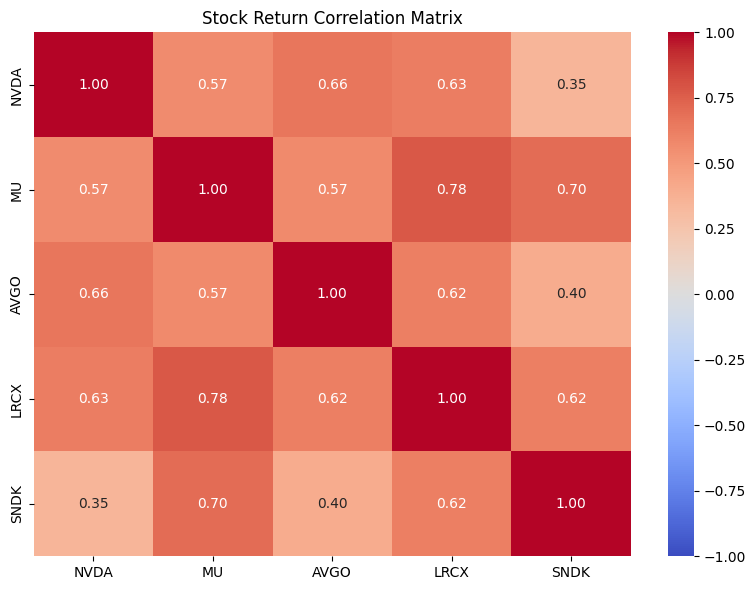

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# calculate correlation matrix
correlation_matrix = returns_df.corr()

print("Correlation Matrix:")
print(correlation_matrix.round(2))

# visualise as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Stock Return Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# sharpe ratio calculation
risk_free_rate = 0.043  # US 10 year treasury yield 4.3%

sharpe_ratios = {}

for ticker in final_companies:
    stock_return = annualised_returns[ticker]
    stock_volatility = annualised_volatility[ticker]
    sharpe = (stock_return - risk_free_rate) / stock_volatility
    sharpe_ratios[ticker] = round(sharpe, 2)

sharpe_df = pd.DataFrame.from_dict(
    sharpe_ratios,
    orient="index",
    columns=["Sharpe Ratio"]
)

# merge with our existing summary
summary_df["Sharpe Ratio"] = sharpe_df["Sharpe Ratio"]
summary_df["Beta"] = beta_df["Beta"]

print("Complete risk and return summary:")
summary_df

Complete risk and return summary:


,Annualised Return (%),Annualised Volatility (%),Sharpe Ratio,Beta
NVDA,40.38,43.19,0.84,1.83
MU,205.16,71.25,2.82,2.47
AVGO,51.73,50.41,0.94,1.86
LRCX,128.73,55.01,2.26,2.24
SNDK,350.16,99.64,3.47,2.68


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# number of simulations
num_simulations = 10000
num_stocks = len(final_companies)
risk_free_rate = 0.043

# store results
simulation_returns = []
simulation_volatilities = []
simulation_sharpes = []
simulation_weights = []

# mean returns and covariance matrix
mean_returns = returns_df.mean()
cov_matrix = returns_df.cov()

# run simulations
for i in range(num_simulations):
    # generate random weights that sum to 1
    weights = np.random.random(num_stocks)
    weights = weights / np.sum(weights)

    # portfolio return
    port_return = np.sum(mean_returns * weights) * 252

    # portfolio volatility
    port_volatility = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix * 252, weights))
    )

    # sharpe ratio
    sharpe = (port_return - risk_free_rate) / port_volatility

    # store results
    simulation_returns.append(port_return)
    simulation_volatilities.append(port_volatility)
    simulation_sharpes.append(sharpe)
    simulation_weights.append(weights)

print(f"Completed {num_simulations} simulations")

Completed 10000 simulations


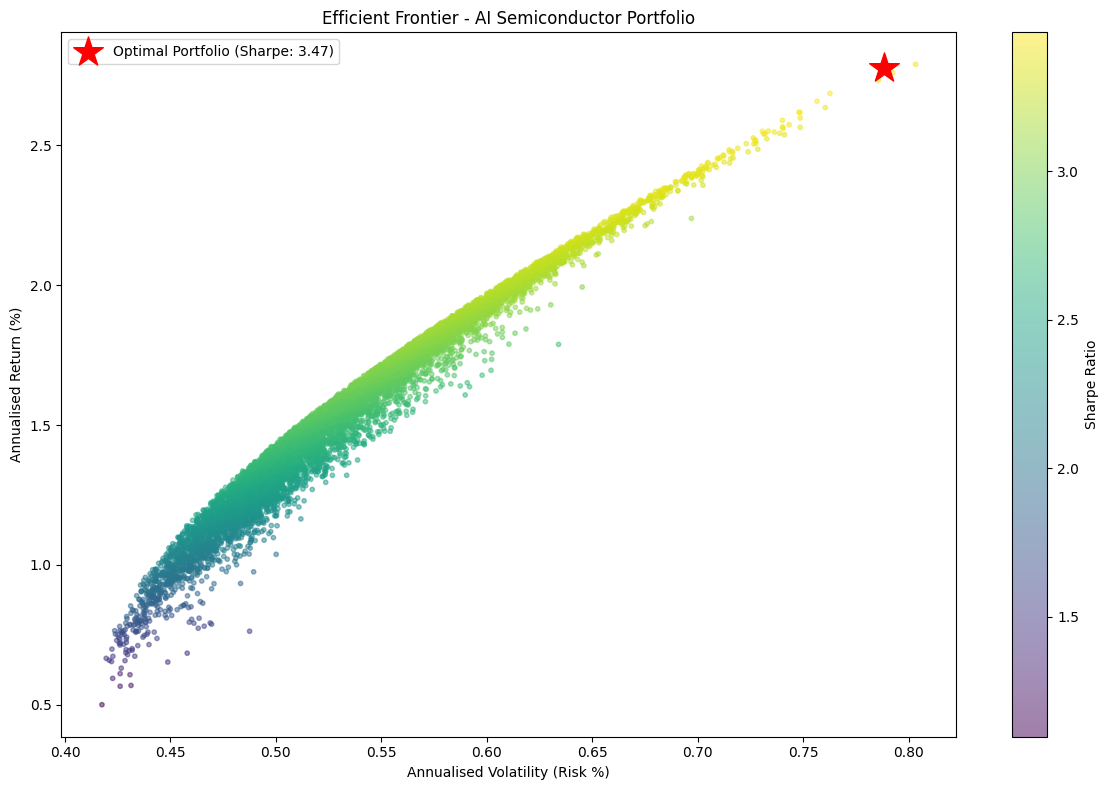


Optimal Portfolio Allocation:
Expected Return: 277.74%
Expected Volatility: 78.85%
Sharpe Ratio: 3.47

Allocation:
NVDA: 0.26%
MU: 24.41%
AVGO: 6.77%
LRCX: 7.24%
SNDK: 61.33%


In [ ]:
# convert to arrays
simulation_returns = np.array(simulation_returns)
simulation_volatilities = np.array(simulation_volatilities)
simulation_sharpes = np.array(simulation_sharpes)
simulation_weights = np.array(simulation_weights)

# find optimal portfolio - highest sharpe ratio
optimal_idx = np.argmax(simulation_sharpes)
optimal_return = simulation_returns[optimal_idx]
optimal_volatility = simulation_volatilities[optimal_idx]
optimal_sharpe = simulation_sharpes[optimal_idx]
optimal_weights = simulation_weights[optimal_idx]

# plot efficient frontier
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    simulation_volatilities,
    simulation_returns,
    c=simulation_sharpes,
    cmap="viridis",
    alpha=0.5,
    s=10
)
plt.colorbar(scatter, label="Sharpe Ratio")

# mark optimal portfolio
plt.scatter(
    optimal_volatility,
    optimal_return,
    color="red",
    marker="*",
    s=500,
    label=f"Optimal Portfolio (Sharpe: {optimal_sharpe:.2f})"
)

plt.xlabel("Annualised Volatility (Risk %)")
plt.ylabel("Annualised Return (%)")
plt.title("Efficient Frontier - AI Semiconductor Portfolio")
plt.legend()
plt.tight_layout()
plt.show()

# print optimal weights
print("\nOptimal Portfolio Allocation:")
print(f"Expected Return: {optimal_return*100:.2f}%")
print(f"Expected Volatility: {optimal_volatility*100:.2f}%")
print(f"Sharpe Ratio: {optimal_sharpe:.2f}")
print("\nAllocation:")
for ticker, weight in zip(final_companies, optimal_weights):
    print(f"{ticker}: {weight*100:.2f}%")

In [ ]:
from scipy.optimize import minimize

# constraint - weights sum to 1
constraints = [
    {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
]

# bounds - each stock between 5% and 35%
bounds = tuple((0.05, 0.35) for _ in range(num_stocks))

# function to minimise - negative sharpe ratio
# we minimise negative sharpe = maximise sharpe
def negative_sharpe(weights):
    port_return = np.sum(mean_returns * weights) * 252
    port_volatility = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix * 252, weights))
    )
    sharpe = (port_return - risk_free_rate) / port_volatility
    return -sharpe

# starting point - equal weights
initial_weights = np.array([1/num_stocks] * num_stocks)

# run optimisation
result = minimize(
    negative_sharpe,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

# extract optimal weights
constrained_weights = result.x
constrained_return = np.sum(mean_returns * constrained_weights) * 252
constrained_volatility = np.sqrt(
    np.dot(constrained_weights.T,
    np.dot(cov_matrix * 252, constrained_weights))
)
constrained_sharpe = (constrained_return - risk_free_rate) / constrained_volatility

print("Constrained Optimal Portfolio (5% min, 35% max per stock):")
print(f"Expected Return: {constrained_return*100:.2f}%")
print(f"Expected Volatility: {constrained_volatility*100:.2f}%")
print(f"Sharpe Ratio: {constrained_sharpe:.2f}")
print("\nAllocation:")
for ticker, weight in zip(final_companies, constrained_weights):
    print(f"{ticker}: {weight*100:.2f}%")

Constrained Optimal Portfolio (5% min, 35% max per stock):
Expected Return: 224.71%
Expected Volatility: 66.45%
Sharpe Ratio: 3.32

Allocation:
NVDA: 5.00%
MU: 35.00%
AVGO: 5.00%
LRCX: 20.00%
SNDK: 35.00%


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

# updated final companies without SNDK
final_companies_4 = ["NVDA", "MU", "AVGO", "LRCX"]
risk_free_rate = 0.043

# fetch 3 years of price data
price_data_4 = {}
for ticker in final_companies_4:
    stock = yf.Ticker(ticker)
    history = stock.history(period="3y")
    history = history.dropna(subset=["Close"])
    price_data_4[ticker] = history["Close"]
    print(f"✓ {ticker}: {len(history)} days of data")

# combine into one table
prices_df_4 = pd.DataFrame(price_data_4)

# calculate daily returns
returns_df_4 = prices_df_4.pct_change().dropna()
print(f"\nTotal trading days: {len(returns_df_4)}")

# annualised return and volatility
annualised_returns_4 = returns_df_4.mean() * 252
annualised_volatility_4 = returns_df_4.std() * np.sqrt(252)

# sharpe ratios
sharpe_ratios_4 = (annualised_returns_4 - risk_free_rate) / annualised_volatility_4

# beta calculation
sp500 = yf.Ticker("^GSPC")
sp500_history = sp500.history(period="3y")
sp500_history = sp500_history.dropna(subset=["Close"])
sp500_returns = sp500_history["Close"].pct_change().dropna()
sp500_returns.index = sp500_returns.index.tz_localize(None)
returns_df_4.index = returns_df_4.index.tz_localize(None)
aligned_sp500 = sp500_returns.reindex(returns_df_4.index).dropna()
aligned_returns_4 = returns_df_4.reindex(aligned_sp500.index).dropna()

betas_4 = {}
for ticker in final_companies_4:
    covariance = aligned_returns_4[ticker].cov(aligned_sp500)
    market_variance = aligned_sp500.var()
    betas_4[ticker] = round(covariance / market_variance, 2)

# summary table
summary_df_4 = pd.DataFrame({
    "Annualised Return (%)": round(annualised_returns_4 * 100, 2),
    "Annualised Volatility (%)": round(annualised_volatility_4 * 100, 2),
    "Sharpe Ratio": round(sharpe_ratios_4, 2),
    "Beta": pd.Series(betas_4)
})

print("\nRisk and Return Summary:")
print(summary_df_4)

# correlation matrix
correlation_matrix_4 = returns_df_4.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix_4.round(2))

✓ NVDA: 752 days of data
✓ MU: 752 days of data
✓ AVGO: 752 days of data
✓ LRCX: 752 days of data

Total trading days: 751

Risk and Return Summary:
      Annualised Return (%)  Annualised Volatility (%)  Sharpe Ratio  Beta
NVDA                  62.81                      46.94          1.25  2.11
MU                   110.22                      59.34          1.79  2.29
AVGO                  64.05                      49.31          1.21  2.04
LRCX                  72.81                      47.43          1.44  2.16

Correlation Matrix:
      NVDA    MU  AVGO  LRCX
NVDA  1.00  0.52  0.62  0.59
MU    0.52  1.00  0.56  0.74
AVGO  0.62  0.56  1.00  0.62
LRCX  0.59  0.74  0.62  1.00


10,000 simulations complete

Constrained Optimal Portfolio (5% min, 40% max per stock):
Expected Return: 84.25%
Expected Volatility: 44.78%
Sharpe Ratio: 1.79

Allocation:
NVDA: 25.34%
MU: 40.00%
AVGO: 11.35%
LRCX: 23.31%


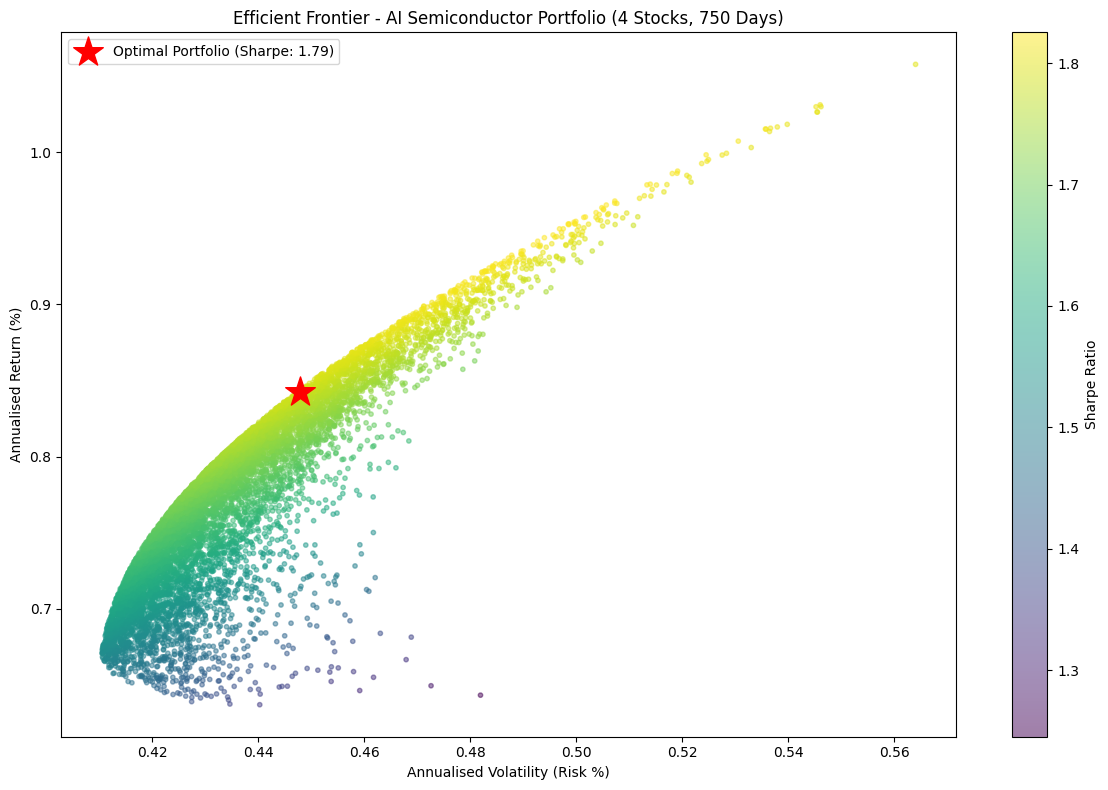

In [ ]:
# monte carlo with 4 stocks 750 days
num_simulations = 10000
num_stocks_4 = len(final_companies_4)
mean_returns_4 = returns_df_4.mean()
cov_matrix_4 = returns_df_4.cov()

simulation_returns_4 = []
simulation_volatilities_4 = []
simulation_sharpes_4 = []
simulation_weights_4 = []

for i in range(num_simulations):
    weights = np.random.random(num_stocks_4)
    weights = weights / np.sum(weights)

    port_return = np.sum(mean_returns_4 * weights) * 252
    port_volatility = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix_4 * 252, weights))
    )
    sharpe = (port_return - risk_free_rate) / port_volatility

    simulation_returns_4.append(port_return)
    simulation_volatilities_4.append(port_volatility)
    simulation_sharpes_4.append(sharpe)
    simulation_weights_4.append(weights)

simulation_returns_4 = np.array(simulation_returns_4)
simulation_volatilities_4 = np.array(simulation_volatilities_4)
simulation_sharpes_4 = np.array(simulation_sharpes_4)
simulation_weights_4 = np.array(simulation_weights_4)

print("10,000 simulations complete")

# constrained optimisation
def negative_sharpe_4(weights):
    port_return = np.sum(mean_returns_4 * weights) * 252
    port_volatility = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix_4 * 252, weights))
    )
    return -(port_return - risk_free_rate) / port_volatility

constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]
bounds = tuple((0.05, 0.40) for _ in range(num_stocks_4))
initial_weights = np.array([1/num_stocks_4] * num_stocks_4)

result = minimize(
    negative_sharpe_4,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

constrained_weights_4 = result.x
constrained_return_4 = np.sum(mean_returns_4 * constrained_weights_4) * 252
constrained_volatility_4 = np.sqrt(
    np.dot(constrained_weights_4.T,
    np.dot(cov_matrix_4 * 252, constrained_weights_4))
)
constrained_sharpe_4 = (constrained_return_4 - risk_free_rate) / constrained_volatility_4

print("\nConstrained Optimal Portfolio (5% min, 40% max per stock):")
print(f"Expected Return: {constrained_return_4*100:.2f}%")
print(f"Expected Volatility: {constrained_volatility_4*100:.2f}%")
print(f"Sharpe Ratio: {constrained_sharpe_4:.2f}")
print("\nAllocation:")
for ticker, weight in zip(final_companies_4, constrained_weights_4):
    print(f"{ticker}: {weight*100:.2f}%")

# plot efficient frontier
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    simulation_volatilities_4,
    simulation_returns_4,
    c=simulation_sharpes_4,
    cmap="viridis",
    alpha=0.5,
    s=10
)
plt.colorbar(scatter, label="Sharpe Ratio")
plt.scatter(
    constrained_volatility_4,
    constrained_return_4,
    color="red",
    marker="*",
    s=500,
    label=f"Optimal Portfolio (Sharpe: {constrained_sharpe_4:.2f})"
)
plt.xlabel("Annualised Volatility (Risk %)")
plt.ylabel("Annualised Return (%)")
plt.title("Efficient Frontier - AI Semiconductor Portfolio (4 Stocks, 750 Days)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# unconstrained optimal portfolio
optimal_idx_4 = np.argmax(simulation_sharpes_4)
unconstrained_weights_4 = simulation_weights_4[optimal_idx_4]
unconstrained_return_4 = simulation_returns_4[optimal_idx_4]
unconstrained_volatility_4 = simulation_volatilities_4[optimal_idx_4]
unconstrained_sharpe_4 = simulation_sharpes_4[optimal_idx_4]

# build comparison table
comparison_df = pd.DataFrame({
    "Stock": final_companies_4,
    "Unconstrained Weight (%)": [round(w * 100, 2) for w in unconstrained_weights_4],
    "Constrained Weight (%)": [round(w * 100, 2) for w in constrained_weights_4]
})

# add portfolio metrics at the bottom
metrics_row = pd.DataFrame({
    "Stock": ["Expected Return (%)", "Volatility (%)", "Sharpe Ratio"],
    "Unconstrained Weight (%)": [
        round(unconstrained_return_4 * 100, 2),
        round(unconstrained_volatility_4 * 100, 2),
        round(unconstrained_sharpe_4, 2)
    ],
    "Constrained Weight (%)": [
        round(constrained_return_4 * 100, 2),
        round(constrained_volatility_4 * 100, 2),
        round(constrained_sharpe_4, 2)
    ]
})

final_comparison = pd.concat([comparison_df, metrics_row], ignore_index=True)
print("Portfolio Comparison — Unconstrained vs Constrained:")
final_comparison

Portfolio Comparison — Unconstrained vs Constrained:


,Stock,Unconstrained Weight (%),Constrained Weight (%)
0,NVDA,20.92,25.34
1,MU,67.47,40.00
2,AVGO,7.59,11.35
3,LRCX,4.02,23.31
4,Expected Return (%),95.29,84.25
5,Volatility (%),49.85,44.78
6,Sharpe Ratio,1.83,1.79


In [ ]:
import numpy as np

# final allocation - qualitative overlay on quantitative output
final_weights = {
    "MU": 0.40,
    "SNDK": 0.25,
    "NVDA": 0.20,
    "AVGO": 0.10,
    "LRCX": 0.05
}

# convert to array in same order as final_companies
weight_array = np.array([final_weights[t] for t in final_companies])

# verify weights sum to 100%
print(f"Total allocation: {weight_array.sum() * 100:.0f}%")

# get returns and covariance from 335 day dataset
mean_returns_final = returns_df.mean()
cov_matrix_final = returns_df.cov()

# portfolio annualised return
port_return = np.sum(mean_returns_final * weight_array) * 252

# portfolio annualised volatility
port_volatility = np.sqrt(
    np.dot(weight_array.T, np.dot(cov_matrix_final * 252, weight_array))
)

# portfolio sharpe ratio
risk_free_rate = 0.043
port_sharpe = (port_return - risk_free_rate) / port_volatility

print(f"\nFinal Portfolio Metrics (Qualitative Overlay Allocation):")
print(f"Expected Annual Return: {port_return * 100:.2f}%")
print(f"Expected Annual Volatility: {port_volatility * 100:.2f}%")
print(f"Sharpe Ratio: {port_sharpe:.2f}")

print(f"\nAllocation Breakdown:")
for ticker, weight in final_weights.items():
    print(f"{ticker}: {weight * 100:.0f}%")

Total allocation: 100%

Final Portfolio Metrics (Qualitative Overlay Allocation):
Expected Annual Return: 189.29%
Expected Annual Volatility: 59.49%
Sharpe Ratio: 3.11

Allocation Breakdown:
MU: 40%
SNDK: 25%
NVDA: 20%
AVGO: 10%
LRCX: 5%


In [ ]:
import numpy as np

# define final companies explicitly
final_companies = ["NVDA", "MU", "AVGO", "LRCX", "SNDK"]

# add LRCX back if missing from screened_df
final_df = screened_df[screened_df["Ticker"].isin(final_companies)].reset_index(drop=True)
if "LRCX" not in final_df["Ticker"].tolist():
    lrcx_row = full_df[full_df["Ticker"] == "LRCX"]
    final_df = pd.concat([final_df, lrcx_row], ignore_index=True)

# final allocation - qualitative overlay
final_weights = {
    "MU": 0.40,
    "SNDK": 0.25,
    "NVDA": 0.20,
    "AVGO": 0.10,
    "LRCX": 0.05
}

weight_array = np.array([final_weights[t] for t in final_companies])

print(f"Total allocation: {weight_array.sum() * 100:.0f}%")

# get returns and covariance from returns_df
mean_returns_final = returns_df[final_companies].mean()
cov_matrix_final = returns_df[final_companies].cov()

# portfolio metrics
port_return = np.sum(mean_returns_final * weight_array) * 252
port_volatility = np.sqrt(
    np.dot(weight_array.T, np.dot(cov_matrix_final * 252, weight_array))
)
risk_free_rate = 0.043
port_sharpe = (port_return - risk_free_rate) / port_volatility

print(f"\nFinal Portfolio Metrics (Qualitative Overlay Allocation):")
print(f"Expected Annual Return:     {port_return * 100:.2f}%")
print(f"Expected Annual Volatility: {port_volatility * 100:.2f}%")
print(f"Sharpe Ratio:               {port_sharpe:.2f}")

print(f"\nAllocation Breakdown:")
for ticker, weight in final_weights.items():
    print(f"  {ticker}: {weight * 100:.0f}%")

Total allocation: 100%

Final Portfolio Metrics (Qualitative Overlay Allocation):
Expected Annual Return:     189.29%
Expected Annual Volatility: 59.49%
Sharpe Ratio:               3.11

Allocation Breakdown:
  MU: 40%
  SNDK: 25%
  NVDA: 20%
  AVGO: 10%
  LRCX: 5%


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# stocks to analyse
stocks_to_analyse = ["NVDA", "MU", "AVGO", "LRCX", "SNDK"]
stock_names = {
    "NVDA": "NVIDIA Corporation",
    "MU": "Micron Technology",
    "AVGO": "Broadcom Inc.",
    "LRCX": "Lam Research Corp.",
    "SNDK": "Sandisk Corporation"
}

def classify_wyckoff_stage(df):
    """
    Classifies a stock into Wyckoff Stage 1, 2, 3 or 4
    based on price action, moving averages and volume
    """

    # moving averages
    df["MA50"] = df["Close"].rolling(50).mean()
    df["MA200"] = df["Close"].rolling(200).mean()
    df["MA20"] = df["Close"].rolling(20).mean()

    # volume moving average
    df["Vol_MA20"] = df["Volume"].rolling(20).mean()

    # price position relative to MAs
    current_price = df["Close"].iloc[-1]
    ma50 = df["MA50"].iloc[-1]
    ma200 = df["MA200"].iloc[-1]
    ma20 = df["MA20"].iloc[-1]

    # trend detection - compare recent highs and lows
    recent_30 = df["Close"].iloc[-30:]
    recent_90 = df["Close"].iloc[-90:]
    prior_90 = df["Close"].iloc[-180:-90]

    recent_high = recent_90.max()
    recent_low = recent_90.min()
    prior_high = prior_90.max()
    prior_low = prior_90.min()

    # is price making higher highs and higher lows?
    higher_highs = recent_high > prior_high
    higher_lows = recent_low > prior_low
    lower_highs = recent_high < prior_high
    lower_lows = recent_low < prior_low

    # volume analysis - is volume higher on up days or down days?
    df["Daily_Return"] = df["Close"].pct_change()
    up_days = df[df["Daily_Return"] > 0]["Volume"].mean()
    down_days = df[df["Daily_Return"] < 0]["Volume"].mean()
    volume_up_bias = up_days > down_days

    # volatility - is range expanding or contracting?
    df["Range"] = df["High"] - df["Low"]
    recent_range = df["Range"].iloc[-30:].mean()
    prior_range = df["Range"].iloc[-90:-30].mean()
    range_expanding = recent_range > prior_range

    # price momentum - last 30 days vs prior 30 days
    recent_return = (df["Close"].iloc[-1] / df["Close"].iloc[-30] - 1) * 100
    prior_return = (df["Close"].iloc[-30] / df["Close"].iloc[-60] - 1) * 100
    momentum_accelerating = recent_return > prior_return

    # sideways detection - low range relative to price
    price_range_pct = (recent_high - recent_low) / recent_low * 100
    is_sideways = price_range_pct < 15

    # STAGE CLASSIFICATION LOGIC
    # Stage 2 - Markup: price above both MAs, higher highs and lows, volume on up days
    if (current_price > ma50 > ma200 and
        higher_highs and higher_lows and
        volume_up_bias):
        stage = 2
        stage_name = "Stage 2 — Markup"
        description = "Uptrend confirmed. Price above both MAs with higher highs and lows. Volume supporting the move up."
        color = "#70AD47"

    # Stage 1 - Accumulation: sideways after downtrend, volume drying up
    elif (is_sideways and
          current_price < ma200 and
          not lower_lows):
        stage = 1
        stage_name = "Stage 1 — Accumulation"
        description = "Sideways movement after decline. Smart money quietly accumulating. Watch for breakout."
        color = "#FFC000"

    # Stage 3 - Distribution: sideways at highs, volume irregular, momentum slowing
    elif (is_sideways and
          current_price > ma200 and
          not momentum_accelerating):
        stage = 3
        stage_name = "Stage 3 — Distribution"
        description = "Sideways at elevated prices. Momentum slowing. Institutions may be distributing to retail buyers."
        color = "#FF7F00"

    # Stage 4 - Markdown: price below MAs, lower highs and lows
    elif (current_price < ma50 and
          current_price < ma200 and
          lower_highs and lower_lows):
        stage = 4
        stage_name = "Stage 4 — Markdown"
        description = "Downtrend confirmed. Price below both MAs with lower highs and lows. Avoid or short."
        color = "#FF0000"

    # Late Stage 2 / Early Stage 3 boundary
    elif (current_price > ma50 and
          higher_highs and
          not momentum_accelerating and
          not volume_up_bias):
        stage = 2.5
        stage_name = "Late Stage 2 / Early Stage 3"
        description = "Uptrend intact but momentum slowing and volume shifting to down days. Monitor closely."
        color = "#FFA500"

    else:
        stage = 0
        stage_name = "Transitional"
        description = "Mixed signals. Cannot clearly classify into a single stage. Monitor for clearer pattern."
        color = "#808080"

    metrics = {
        "Current Price": round(current_price, 2),
        "MA20": round(ma20, 2),
        "MA50": round(ma50, 2),
        "MA200": round(ma200, 2),
        "Price vs MA50": "Above" if current_price > ma50 else "Below",
        "Price vs MA200": "Above" if current_price > ma200 else "Below",
        "Higher Highs": higher_highs,
        "Higher Lows": higher_lows,
        "Volume Bias": "Up days" if volume_up_bias else "Down days",
        "30D Return (%)": round(recent_return, 2),
        "Momentum": "Accelerating" if momentum_accelerating else "Slowing"
    }

    return stage, stage_name, description, color, metrics, df

# run analysis for all stocks
print("WYCKOFF STAGE ANALYSIS")
print("=" * 70)

stage_results = {}

for ticker in stocks_to_analyse:
    stock = yf.Ticker(ticker)
    df = stock.history(period="1y")
    df = df.dropna()

    stage, stage_name, description, color, metrics, df_with_mas = classify_wyckoff_stage(df)
    stage_results[ticker] = {
        "stage": stage,
        "stage_name": stage_name,
        "description": description,
        "color": color,
        "metrics": metrics,
        "df": df_with_mas
    }

    print(f"\n{ticker} — {stock_names[ticker]}")
    print(f"Stage: {stage_name}")
    print(f"Description: {description}")
    print(f"Key Metrics:")
    for k, v in metrics.items():
        print(f"  {k}: {v}")
    print("-" * 70)

WYCKOFF STAGE ANALYSIS

NVDA — NVIDIA Corporation
Stage: Transitional
Description: Mixed signals. Cannot clearly classify into a single stage. Monitor for clearer pattern.
Key Metrics:
  Current Price: 199.0
  MA20: 209.62
  MA50: 210.05
  MA200: 190.18
  Price vs MA50: Below
  Price vs MA200: Above
  Higher Highs: True
  Higher Lows: False
  Volume Bias: Down days
  30D Return (%): -9.76
  Momentum: Slowing
----------------------------------------------------------------------

MU — Micron Technology
Stage: Stage 2 — Markup
Description: Uptrend confirmed. Price above both MAs with higher highs and lows. Volume supporting the move up.
Key Metrics:
  Current Price: 1048.51
  MA20: 1010.71
  MA50: 773.66
  MA200: 415.31
  Price vs MA50: Above
  Price vs MA200: Above
  Higher Highs: True
  Higher Lows: True
  Volume Bias: Up days
  30D Return (%): 36.78
  Momentum: Slowing
----------------------------------------------------------------------

AVGO — Broadcom Inc.
Stage: Transitional
Desc

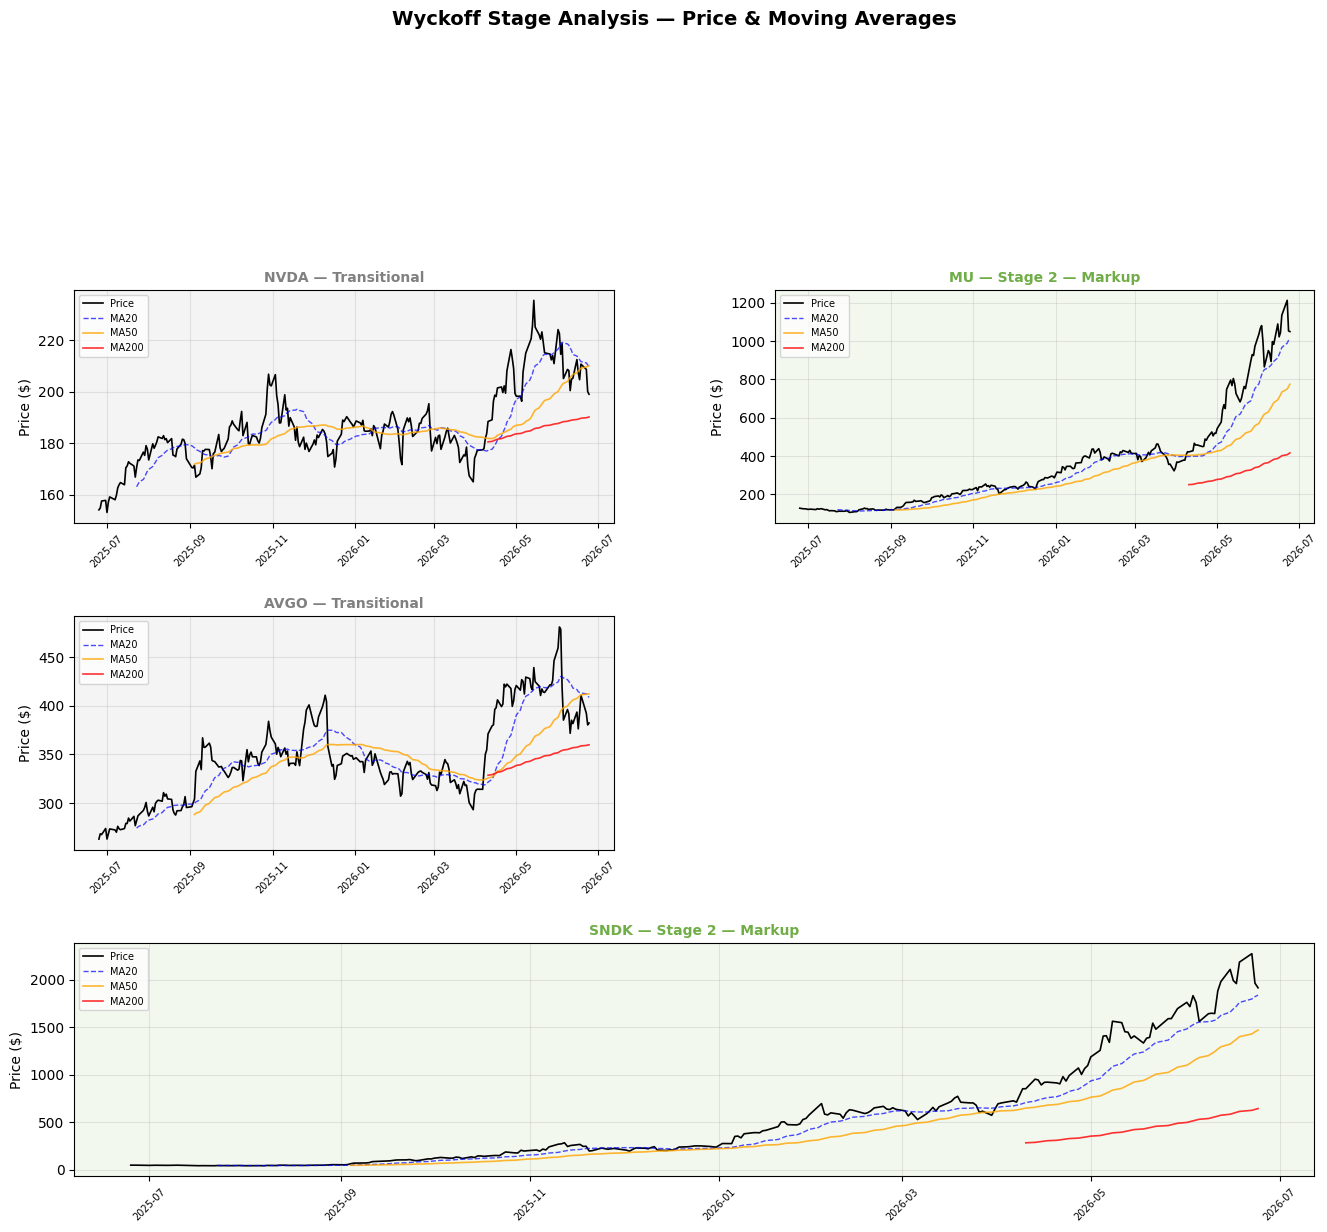

Charts generated


In [ ]:
fig = plt.figure(figsize=(16, 20))
gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.4, wspace=0.3)

for idx, ticker in enumerate(stocks_to_analyse):
    row = idx // 2
    col = idx % 2

    if idx < 4:
        ax_price = fig.add_subplot(gs[row, col])
    else:
        ax_price = fig.add_subplot(gs[2, :])

    data = stage_results[ticker]
    df = data["df"].iloc[-252:]  # last 1 year
    stage_color = data["color"]

    # price and moving averages
    ax_price.plot(df.index, df["Close"],
                  color='black', linewidth=1.2, label='Price')
    ax_price.plot(df.index, df["MA20"],
                  color='blue', linewidth=1, linestyle='--',
                  alpha=0.7, label='MA20')
    ax_price.plot(df.index, df["MA50"],
                  color='orange', linewidth=1.2,
                  alpha=0.8, label='MA50')
    ax_price.plot(df.index, df["MA200"],
                  color='red', linewidth=1.2,
                  alpha=0.8, label='MA200')

    # shade the stage background
    ax_price.set_facecolor(stage_color + "15")

    # add stage label
    ax_price.set_title(
        f"{ticker} — {data['stage_name']}",
        fontsize=10, fontweight='bold',
        color=stage_color
    )
    ax_price.set_ylabel("Price ($)")
    ax_price.legend(fontsize=7, loc='upper left')
    ax_price.grid(True, alpha=0.3)
    ax_price.tick_params(axis='x', rotation=45, labelsize=7)

# remove empty subplot if odd number
if len(stocks_to_analyse) % 2 != 0:
    fig.delaxes(fig.axes[-2])

plt.suptitle("Wyckoff Stage Analysis — Price & Moving Averages",
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig('/tmp/wyckoff_stages.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts generated")

In [ ]:
# Clean Summary Table - Wyckoff Stage Analysis
# All 5 stocks as columns, metrics as rows

summary_data = {
    "Metric": [
        "Current Price ($)",
        "MA20 ($)",
        "MA50 ($)",
        "MA200 ($)",
        "Price vs MA20",
        "Price vs MA50",
        "Price vs MA200",
        "Higher Highs",
        "Higher Lows",
        "Volume Bias",
        "30D Return (%)",
        "Momentum",
        "MA20 Signal",
        "MA50 Signal",
        "MA200 Signal",
        "Volume Signal",
        "Momentum Signal",
        "━━━━━━━━━━━━━━",
        "WYCKOFF STAGE",
        "OVERALL SIGNAL"
    ]
}

signal_map = {
    True: "✓ Yes",
    False: "✗ No"
}

def price_vs_ma_signal(price, ma):
    if price > ma:
        return f"Above ↑ (Bullish)"
    else:
        return f"Below ↓ (Bearish)"

def volume_signal(bias):
    if bias == "Up days":
        return "Up Days (Bullish)"
    else:
        return "Down Days (Bearish)"

def momentum_signal(momentum):
    if momentum == "Accelerating":
        return "Accelerating (Bullish)"
    else:
        return "Slowing (Caution)"

def overall_signal(stage):
    signals = {
        2: "BUY — Strong Uptrend",
        2.5: "HOLD — Monitor Closely",
        3: "CAUTION — Consider Exit",
        1: "WATCH — Accumulation",
        4: "AVOID — Downtrend",
        0: "WAIT — Mixed Signals"
    }
    return signals.get(stage, "WAIT — Mixed Signals")

def count_bullish(metrics, stage_data):
    score = 0
    if "Above" in price_vs_ma_signal(metrics["Current Price"], metrics["MA20"]):
        score += 1
    if "Above" in price_vs_ma_signal(metrics["Current Price"], metrics["MA50"]):
        score += 1
    if "Above" in price_vs_ma_signal(metrics["Current Price"], metrics["MA200"]):
        score += 1
    if metrics["Volume Bias"] == "Up days":
        score += 1
    if metrics["Momentum"] == "Accelerating":
        score += 1
    return f"{score}/5 Bullish"

for ticker in stocks_to_analyse:
    data = stage_results[ticker]
    metrics = data["metrics"]
    stage = data["stage"]
    stage_name = data["stage_name"]

    col_data = [
        f"${metrics['Current Price']:,.2f}",
        f"${metrics['MA20']:,.2f}",
        f"${metrics['MA50']:,.2f}",
        f"${metrics['MA200']:,.2f}",
        price_vs_ma_signal(metrics["Current Price"], metrics["MA20"]),
        price_vs_ma_signal(metrics["Current Price"], metrics["MA50"]),
        price_vs_ma_signal(metrics["Current Price"], metrics["MA200"]),
        signal_map[metrics["Higher Highs"]],
        signal_map[metrics["Higher Lows"]],
        metrics["Volume Bias"],
        f"{metrics['30D Return (%)']:+.2f}%",
        metrics["Momentum"],
        "Bullish" if metrics["Current Price"] > metrics["MA20"] else "Bearish",
        "Bullish" if metrics["Current Price"] > metrics["MA50"] else "Bearish",
        "Bullish" if metrics["Current Price"] > metrics["MA200"] else "Bearish",
        "Bullish" if metrics["Volume Bias"] == "Up days" else "Bearish",
        "Bullish" if metrics["Momentum"] == "Accelerating" else "Caution",
        "━━━━━━━━━━━━━━",
        stage_name,
        overall_signal(stage)
    ]

    summary_data[f"{ticker}\n({stock_names[ticker]})"] = col_data

summary_table = pd.DataFrame(summary_data)
summary_table = summary_table.set_index("Metric")

print("WYCKOFF STAGE ANALYSIS — SUMMARY TABLE")
print("=" * 120)
print(summary_table.to_string())
print("=" * 120)

# also print a clean action summary
print("\nACTION SUMMARY")
print("-" * 60)
for ticker in stocks_to_analyse:
    data = stage_results[ticker]
    metrics = data["metrics"]
    stage = data["stage"]
    signal = overall_signal(stage)
    bullish_count = count_bullish(metrics, data)
    print(f"{ticker:<6} | {data['stage_name']:<35} | {bullish_count} | {signal}")

WYCKOFF STAGE ANALYSIS — SUMMARY TABLE
                  NVDA\n(NVIDIA Corporation) MU\n(Micron Technology) AVGO\n(Broadcom Inc.)    LRCX\n(Lam Research Corp.) SNDK\n(Sandisk Corporation)
Metric                                                                                                                                              
Current Price ($)                    $199.00               $1,048.51               $382.07                       $374.80                   $1,914.46
MA20 ($)                             $209.62               $1,010.71               $408.36                       $348.32                   $1,837.15
MA50 ($)                             $210.05                 $773.66               $412.02                       $305.29                   $1,469.77
MA200 ($)                            $190.18                 $415.31               $359.68                       $213.98                     $643.10
Price vs MA20              Below ↓ (Bearish)       Above ↑ (Bullish

In [ ]:
# export to excel
summary_table.to_excel("/tmp/wyckoff_analysis.xlsx")
print("Saved to Excel")

Saved to Excel


In [ ]:
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side

# save base table first
summary_table.to_excel("/tmp/wyckoff_analysis.xlsx")

# open and format
wb = openpyxl.load_workbook("/tmp/wyckoff_analysis.xlsx")
ws = wb.active

# colors
green_fill = PatternFill(start_color="E2EFDA", end_color="E2EFDA", fill_type="solid")
red_fill = PatternFill(start_color="FCE4D6", end_color="FCE4D6", fill_type="solid")
yellow_fill = PatternFill(start_color="FFF2CC", end_color="FFF2CC", fill_type="solid")
header_fill = PatternFill(start_color="1F4E79", end_color="1F4E79", fill_type="solid")
stage_fill = PatternFill(start_color="2E75B6", end_color="2E75B6", fill_type="solid")

thin_border = Border(
    left=Side(style='thin', color='CCCCCC'),
    right=Side(style='thin', color='CCCCCC'),
    top=Side(style='thin', color='CCCCCC'),
    bottom=Side(style='thin', color='CCCCCC')
)

# format header row
for cell in ws[1]:
    cell.fill = header_fill
    cell.font = Font(bold=True, color="FFFFFF", size=11)
    cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
    cell.border = thin_border

# format all cells
for row in ws.iter_rows(min_row=2):
    for cell in row:
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
        cell.border = thin_border
        cell.font = Font(size=10)

        if cell.value:
            val = str(cell.value)
            # green for bullish signals
            if any(word in val for word in ["Bullish", "Above", "Up Days",
                                             "Accelerating", "BUY", "✓"]):
                cell.fill = green_fill
            # red for bearish signals
            elif any(word in val for word in ["Bearish", "Below", "Down Days",
                                               "AVOID", "✗"]):
                cell.fill = red_fill
            # yellow for caution signals
            elif any(word in val for word in ["Caution", "HOLD", "WAIT",
                                               "Slowing", "Monitor"]):
                cell.fill = yellow_fill

# format stage and overall signal rows
for row in ws.iter_rows(min_row=2):
    first_cell = row[0]
    if first_cell.value and "STAGE" in str(first_cell.value):
        for cell in row:
            cell.font = Font(bold=True, size=11)
    if first_cell.value and "SIGNAL" in str(first_cell.value):
        for cell in row:
            cell.font = Font(bold=True, size=11)

# column widths
ws.column_dimensions['A'].width = 22
for col in ['B', 'C', 'D', 'E', 'F']:
    ws.column_dimensions[col].width = 28

# row heights
for row in ws.iter_rows():
    ws.row_dimensions[row[0].row].height = 35

# title
ws.insert_rows(1)
ws.merge_cells('A1:F1')
title_cell = ws['A1']
title_cell.value = "WYCKOFF STAGE ANALYSIS — AI Semiconductor Portfolio"
title_cell.fill = PatternFill(start_color="1F4E79",
                               end_color="1F4E79", fill_type="solid")
title_cell.font = Font(bold=True, color="FFFFFF", size=14)
title_cell.alignment = Alignment(horizontal='center', vertical='center')
ws.row_dimensions[1].height = 40

wb.save("/mnt/user-data/outputs/Wyckoff_Stage_Analysis.xlsx")
print("Formatted Excel file saved")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/Wyckoff_Stage_Analysis.xlsx'

In [ ]:
# show momentum calculation clearly for all 5 stocks
print("MOMENTUM BREAKDOWN — Recent 30 Days vs Prior 30 Days")
print("=" * 65)
print(f"{'Ticker':<8} {'Prior 30D Return':<20} {'Recent 30D Return':<20} {'Momentum'}")
print("-" * 65)

for ticker in stocks_to_analyse:
    data = stage_results[ticker]
    df = data["df"]

    # same calculation as classifier
    recent_return = (df["Close"].iloc[-1] / df["Close"].iloc[-30] - 1) * 100
    prior_return = (df["Close"].iloc[-30] / df["Close"].iloc[-60] - 1) * 100

    momentum = "Accelerating" if recent_return > prior_return else "Slowing"

    print(f"{ticker:<8} {prior_return:>+.2f}%{'':<13} {recent_return:>+.2f}%{'':<13} {momentum}")

print("-" * 65)
print("\nLogic: If Recent 30D Return > Prior 30D Return = Accelerating")
print("       If Recent 30D Return < Prior 30D Return = Slowing")

MOMENTUM BREAKDOWN — Recent 30 Days vs Prior 30 Days
Ticker   Prior 30D Return     Recent 30D Return    Momentum
-----------------------------------------------------------------
NVDA     +33.67%              -9.76%              Slowing
MU       +138.22%              +36.78%              Slowing
AVGO     +42.91%              -8.73%              Slowing
LRCX     +44.67%              +29.67%              Slowing
SNDK     +153.63%              +31.85%              Slowing
-----------------------------------------------------------------

Logic: If Recent 30D Return > Prior 30D Return = Accelerating
       If Recent 30D Return < Prior 30D Return = Slowing


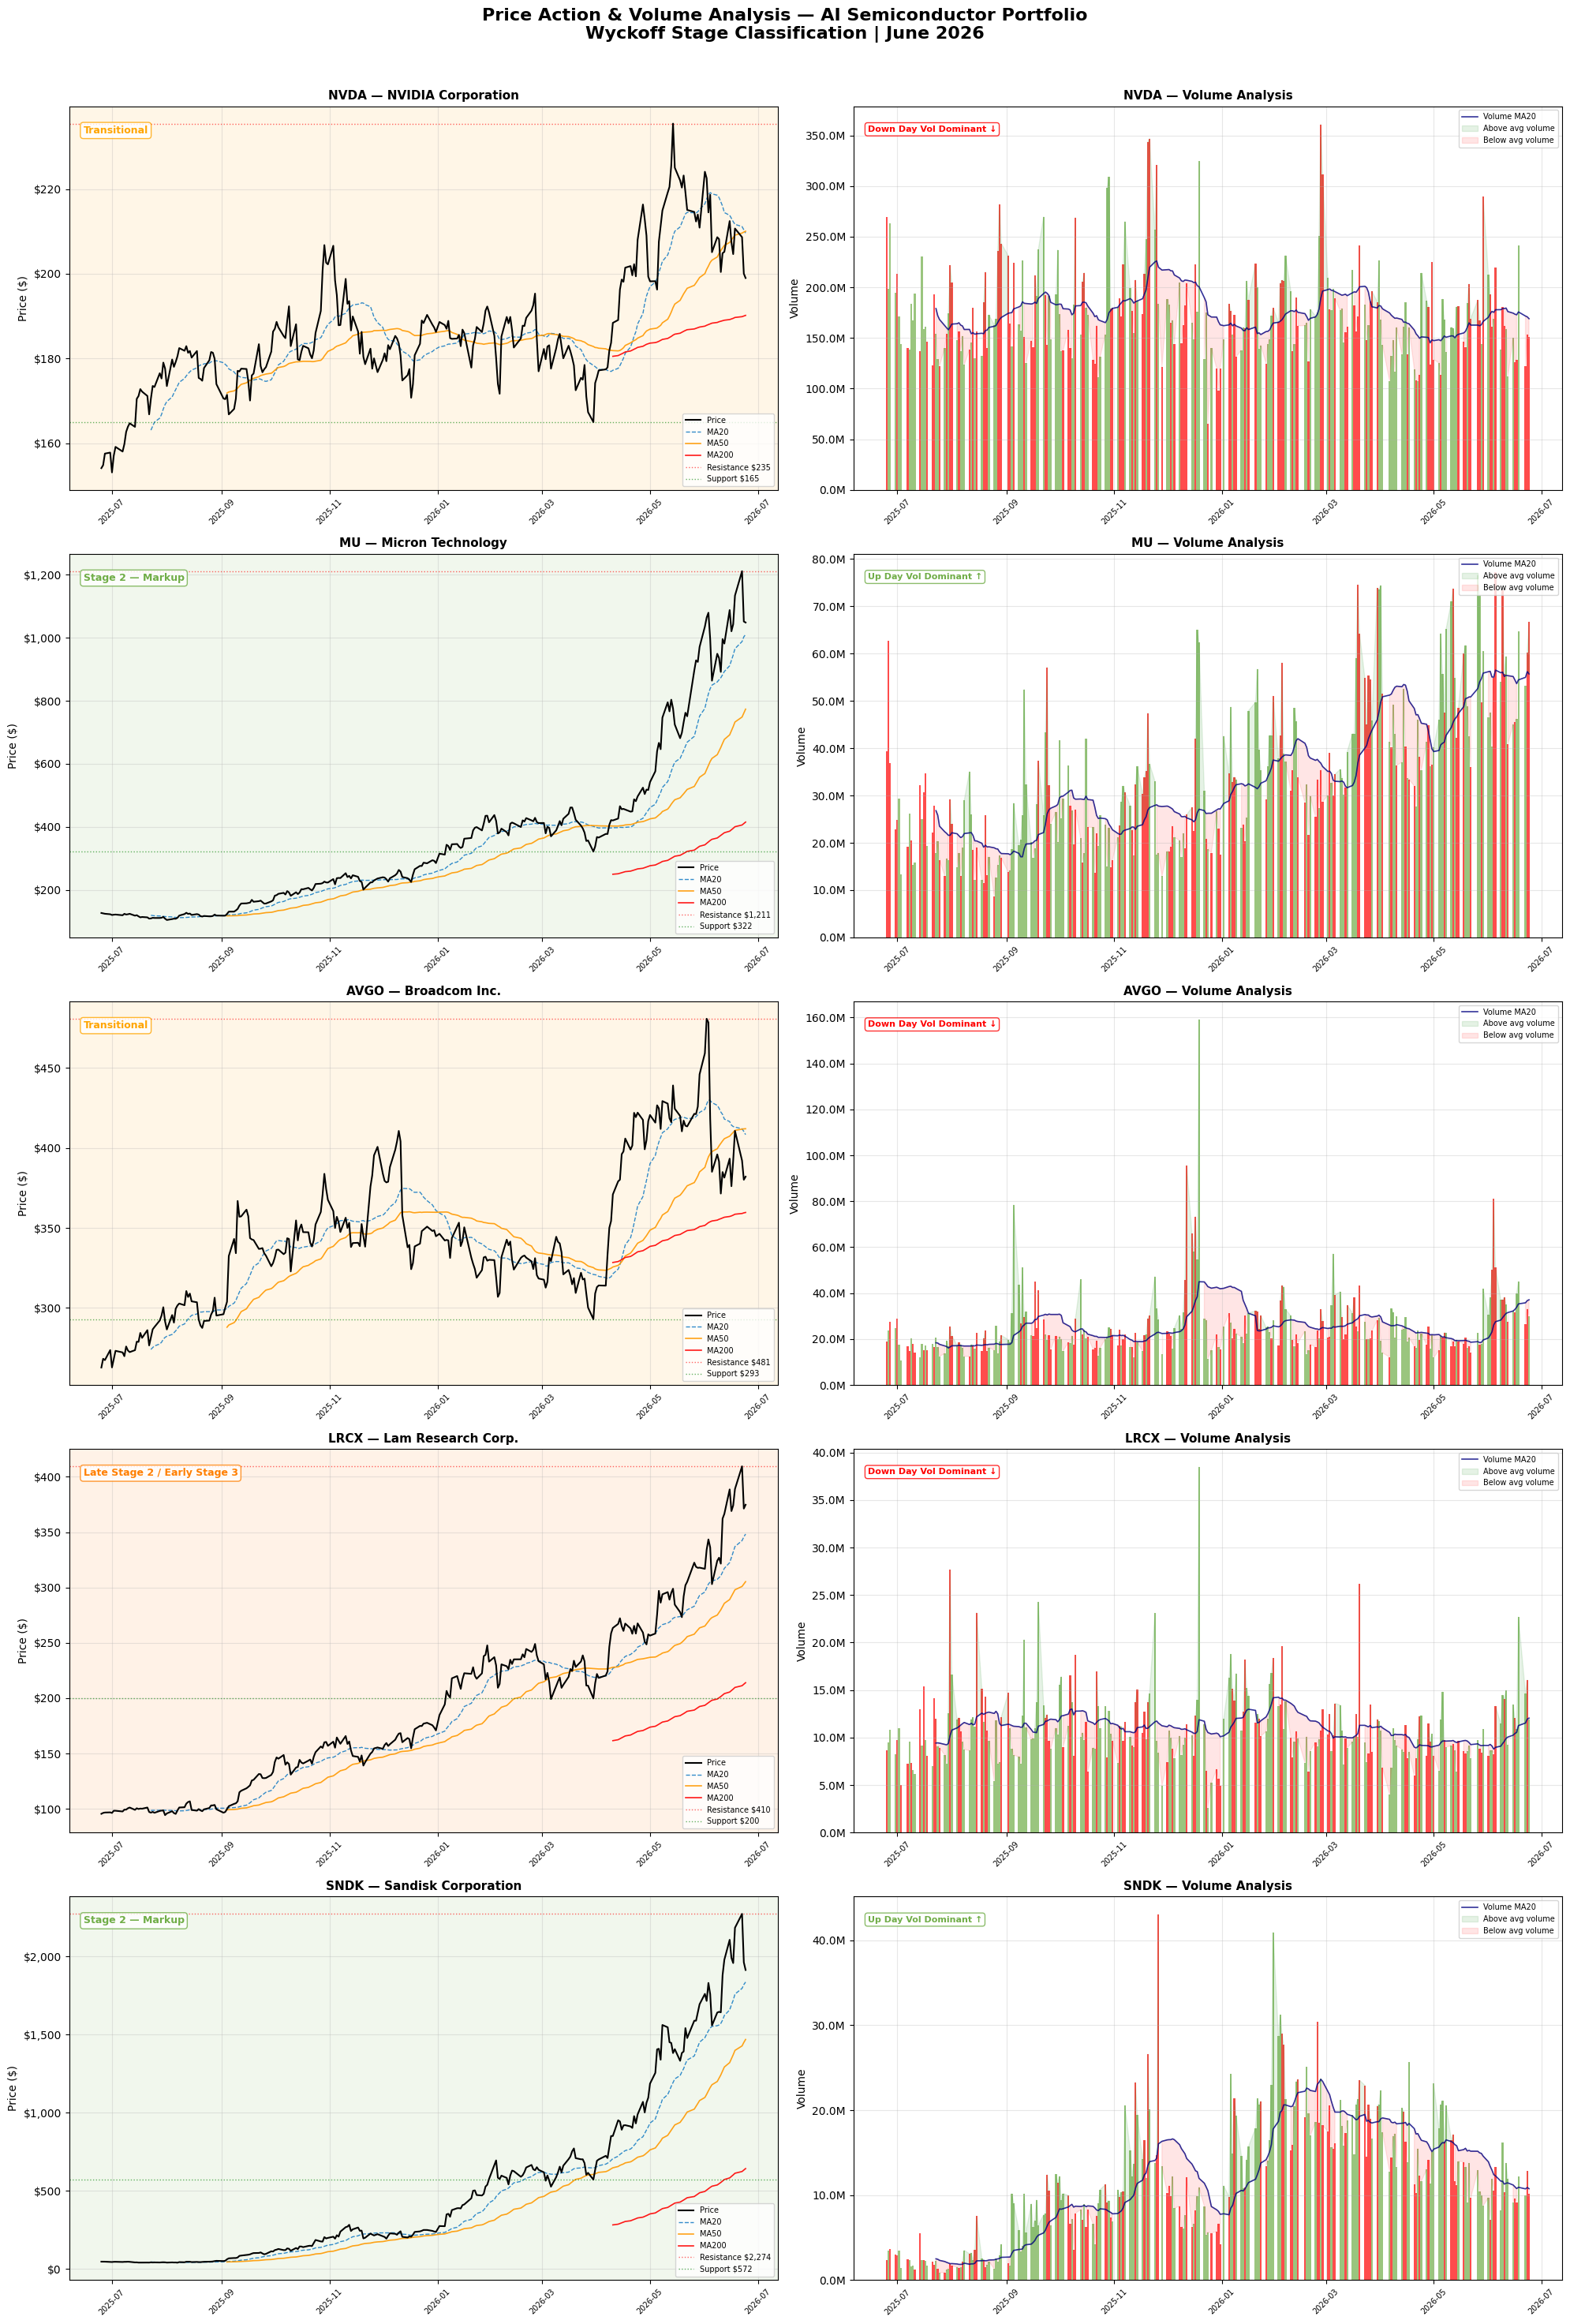

Charts generated successfully


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(20, 30))
fig.suptitle("Price Action & Volume Analysis — AI Semiconductor Portfolio\nWyckoff Stage Classification | June 2026",
             fontsize=16, fontweight='bold', y=0.98)

stage_colors = {
    "NVDA": "#FFA500",  # transitional - orange
    "MU": "#70AD47",    # stage 2 - green
    "AVGO": "#FFA500",  # transitional - orange
    "LRCX": "#FF7F00",  # late stage 2 - amber
    "SNDK": "#70AD47"   # stage 2 - green
}

stage_labels = {
    "NVDA": "Transitional",
    "MU": "Stage 2 — Markup",
    "AVGO": "Transitional",
    "LRCX": "Late Stage 2 / Early Stage 3",
    "SNDK": "Stage 2 — Markup"
}

for idx, ticker in enumerate(stocks_to_analyse):
    # create subplot with price on top, volume on bottom
    ax_price = fig.add_subplot(5, 2, idx*2 + 1)
    ax_volume = fig.add_subplot(5, 2, idx*2 + 2)

    df = stage_results[ticker]["df"].iloc[-252:]
    stage_color = stage_colors[ticker]
    stage_label = stage_labels[ticker]

    dates = df.index

    # ── PRICE PANEL ──────────────────────────────────────────────
    ax_price.plot(dates, df["Close"], color='black',
                  linewidth=1.5, label='Price', zorder=5)
    ax_price.plot(dates, df["MA20"], color='#0070C0',
                  linewidth=1, linestyle='--', alpha=0.8, label='MA20')
    ax_price.plot(dates, df["MA50"], color='#FF9900',
                  linewidth=1.2, alpha=0.9, label='MA50')
    ax_price.plot(dates, df["MA200"], color='#FF0000',
                  linewidth=1.2, alpha=0.9, label='MA200')

    # support and resistance - simple high/low of rolling windows
    rolling_high = df["Close"].rolling(20).max()
    rolling_low = df["Close"].rolling(20).min()

    # key resistance - recent 3 month high
    resistance = df["Close"].iloc[-63:].max()
    support = df["Close"].iloc[-63:].min()

    ax_price.axhline(y=resistance, color='red', linestyle=':',
                     linewidth=1, alpha=0.6, label=f'Resistance ${resistance:,.0f}')
    ax_price.axhline(y=support, color='green', linestyle=':',
                     linewidth=1, alpha=0.6, label=f'Support ${support:,.0f}')

    # shade background with stage color
    ax_price.set_facecolor(stage_color + "18")

    # stage label box
    ax_price.text(0.02, 0.95, stage_label,
                  transform=ax_price.transAxes,
                  fontsize=9, fontweight='bold',
                  color=stage_color,
                  verticalalignment='top',
                  bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='white',
                           edgecolor=stage_color,
                           alpha=0.8))

    ax_price.set_title(f"{ticker} — {stock_names[ticker]}",
                       fontsize=11, fontweight='bold')
    ax_price.set_ylabel("Price ($)")
    ax_price.legend(fontsize=7, loc='lower right')
    ax_price.grid(True, alpha=0.3)
    ax_price.tick_params(axis='x', rotation=45, labelsize=7)
    ax_price.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

    # ── VOLUME PANEL ──────────────────────────────────────────────
    df["Daily_Return"] = df["Close"].pct_change()

    # green bars for up days, red for down days
    colors_vol = ['#70AD47' if r >= 0 else '#FF0000'
                  for r in df["Daily_Return"]]

    ax_volume.bar(dates, df["Volume"],
                  color=colors_vol, alpha=0.7, width=1)

    # volume MA20
    ax_volume.plot(dates, df["Vol_MA20"],
                   color='navy', linewidth=1.2,
                   label='Volume MA20', alpha=0.8)

    # shade above/below volume MA
    ax_volume.fill_between(dates, df["Volume"], df["Vol_MA20"],
                           where=df["Volume"] >= df["Vol_MA20"],
                           alpha=0.1, color='green',
                           label='Above avg volume')
    ax_volume.fill_between(dates, df["Volume"], df["Vol_MA20"],
                           where=df["Volume"] < df["Vol_MA20"],
                           alpha=0.1, color='red',
                           label='Below avg volume')

    ax_volume.set_title(f"{ticker} — Volume Analysis",
                        fontsize=11, fontweight='bold')
    ax_volume.set_ylabel("Volume")
    ax_volume.legend(fontsize=7, loc='upper right')
    ax_volume.grid(True, alpha=0.3)
    ax_volume.tick_params(axis='x', rotation=45, labelsize=7)
    ax_volume.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

    # volume bias annotation
    up_vol = df[df["Daily_Return"] > 0]["Volume"].mean()
    down_vol = df[df["Daily_Return"] < 0]["Volume"].mean()
    bias = "Up Day Vol Dominant ↑" if up_vol > down_vol else "Down Day Vol Dominant ↓"
    bias_color = "#70AD47" if up_vol > down_vol else "#FF0000"

    ax_volume.text(0.02, 0.95, bias,
                   transform=ax_volume.transAxes,
                   fontsize=8, fontweight='bold',
                   color=bias_color,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.3',
                            facecolor='white',
                            edgecolor=bias_color,
                            alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('/tmp/price_volume_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Charts generated successfully")

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from datetime import datetime
import shutil
import os

# ── CONFIGURATION ────────────────────────────────────────────────────────
stocks_to_analyse = ["NVDA", "MU", "AVGO", "LRCX", "SNDK"]
stock_names = {
    "NVDA": "NVIDIA Corporation",
    "MU": "Micron Technology",
    "AVGO": "Broadcom Inc.",
    "LRCX": "Lam Research Corp.",
    "SNDK": "Sandisk Corporation"
}

# ── FETCH FORWARD LOOKING DATA ───────────────────────────────────────────
def get_forward_data(ticker):
    stock = yf.Ticker(ticker)
    info = stock.info

    # METHOD 1 - analyst price targets
    current_price = info.get("currentPrice")
    target_low = info.get("targetLowPrice")
    target_mean = info.get("targetMeanPrice")
    target_high = info.get("targetHighPrice")
    num_analysts = info.get("numberOfAnalystOpinions")
    recommendation = info.get("recommendationKey", "N/A").upper()

    implied_low = round(((target_low - current_price) / current_price) * 100, 2) \
        if target_low and current_price else None
    implied_mean = round(((target_mean - current_price) / current_price) * 100, 2) \
        if target_mean and current_price else None
    implied_high = round(((target_high - current_price) / current_price) * 100, 2) \
        if target_high and current_price else None

    # analyst signal
    if implied_mean is not None:
        if implied_mean > 20:
            analyst_signal = "STRONG BUY"
        elif implied_mean > 5:
            analyst_signal = "BUY"
        elif implied_mean > -5:
            analyst_signal = "NEUTRAL"
        else:
            analyst_signal = "CAUTION"
    else:
        analyst_signal = "NO DATA"

    # METHOD 2 - forward earnings and revenue growth
    earnings_growth = info.get("earningsGrowth")
    revenue_growth = info.get("revenueGrowth")
    forward_eps = info.get("forwardEps")
    trailing_eps = info.get("trailingEps")
    trailing_pe = info.get("trailingPE")
    forward_pe = info.get("forwardPE")
    peg = info.get("trailingPegRatio")

    eps_growth = round(((forward_eps - trailing_eps) / abs(trailing_eps)) * 100, 2) \
        if forward_eps and trailing_eps and trailing_eps != 0 else None

    # score for fundamental signal
    score = 0
    if earnings_growth and earnings_growth * 100 > 15: score += 1
    if earnings_growth and earnings_growth > 0: score += 0.5
    if revenue_growth and revenue_growth * 100 > 10: score += 1
    if eps_growth and eps_growth > 10: score += 1
    if peg and peg < 1: score += 1
    if peg and 1 <= peg <= 2: score += 0.5

    if score >= 3:
        fundamental_signal = "STRONG BUY"
    elif score >= 2:
        fundamental_signal = "BUY"
    elif score >= 1:
        fundamental_signal = "NEUTRAL"
    else:
        fundamental_signal = "CAUTION"

    # combined signal
    signal_scores = {
        "STRONG BUY": 3, "BUY": 2,
        "NEUTRAL": 1, "CAUTION": 0, "NO DATA": 1
    }
    combined_score = (signal_scores[analyst_signal] +
                      signal_scores[fundamental_signal]) / 2

    if combined_score >= 2.5:
        combined_signal = "STRONG BUY"
    elif combined_score >= 1.5:
        combined_signal = "BUY"
    elif combined_score >= 1:
        combined_signal = "NEUTRAL"
    else:
        combined_signal = "CAUTION"

    return {
        # method 1
        "current_price": round(current_price, 2) if current_price else None,
        "target_low": round(target_low, 2) if target_low else None,
        "target_mean": round(target_mean, 2) if target_mean else None,
        "target_high": round(target_high, 2) if target_high else None,
        "implied_low": implied_low,
        "implied_mean": implied_mean,
        "implied_high": implied_high,
        "num_analysts": num_analysts,
        "recommendation": recommendation,
        "analyst_signal": analyst_signal,
        # method 2
        "earnings_growth": round(earnings_growth * 100, 2) if earnings_growth else None,
        "revenue_growth": round(revenue_growth * 100, 2) if revenue_growth else None,
        "trailing_eps": round(trailing_eps, 2) if trailing_eps else None,
        "forward_eps": round(forward_eps, 2) if forward_eps else None,
        "eps_growth": eps_growth,
        "trailing_pe": round(trailing_pe, 2) if trailing_pe else None,
        "forward_pe": round(forward_pe, 2) if forward_pe else None,
        "peg": round(peg, 2) if peg else None,
        "fundamental_signal": fundamental_signal,
        # combined
        "combined_signal": combined_signal
    }

# fetch all stocks
print("Fetching live forward looking data...")
forward_data = {}
for ticker in stocks_to_analyse:
    forward_data[ticker] = get_forward_data(ticker)
    print(f"  ✓ {ticker}")

today = datetime.now().strftime('%A, %d %B %Y')

# ── PRINT TABLE ───────────────────────────────────────────────────────────
col_width = 16
label_width = 28

def fmt(val, rtype):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "N/A"
    if rtype == "price": return f"${val:,.2f}"
    if rtype == "pct": return f"{val:+.2f}%"
    if rtype == "num": return str(val)
    if rtype == "ratio": return f"{val:.2f}x"
    return str(val)

rows_m1 = [
    ("── METHOD 1 — ANALYST PRICE TARGETS ──", None, None),
    ("Current Price ($)", "current_price", "price"),
    ("Target Low ($)", "target_low", "price"),
    ("Target Mean ($)", "target_mean", "price"),
    ("Target High ($)", "target_high", "price"),
    ("Implied Return — Low (%)", "implied_low", "pct"),
    ("Implied Return — Mean (%)", "implied_mean", "pct"),
    ("Implied Return — High (%)", "implied_high", "pct"),
    ("Number of Analysts", "num_analysts", "num"),
    ("Recommendation", "recommendation", "str"),
    ("Analyst Signal", "analyst_signal", "str"),
]

rows_m2 = [
    ("── METHOD 2 — FORWARD EARNINGS & REVENUE ──", None, None),
    ("Earnings Growth (%)", "earnings_growth", "pct"),
    ("Revenue Growth (%)", "revenue_growth", "pct"),
    ("Trailing EPS ($)", "trailing_eps", "price"),
    ("Forward EPS ($)", "forward_eps", "price"),
    ("EPS Growth Implied (%)", "eps_growth", "pct"),
    ("Trailing P/E", "trailing_pe", "ratio"),
    ("Forward P/E", "forward_pe", "ratio"),
    ("PEG Ratio", "peg", "ratio"),
    ("Fundamental Signal", "fundamental_signal", "str"),
]

rows_conclusion = [
    ("── COMBINED CONCLUSION ──", None, None),
    ("COMBINED SIGNAL", "combined_signal", "str"),
]

all_rows = rows_m1 + rows_m2 + rows_conclusion

print(f"\n{'='*108}")
print(f"  FORWARD LOOKING ANALYSIS — {today}")
print(f"  Source: Yahoo Finance via yfinance | Data refreshed live")
print(f"{'='*108}")

header = f"{'Metric':<{label_width}}"
for ticker in stocks_to_analyse:
    header += f"{ticker:^{col_width}}"
print(header)
print("─" * 108)

for label, key, rtype in all_rows:
    if key is None:
        print(f"\n{label}")
        print("─" * 108)
        continue
    row_str = f"{label:<{label_width}}"
    for ticker in stocks_to_analyse:
        val = forward_data[ticker].get(key)
        row_str += f"{fmt(val, rtype):^{col_width}}"
    print(row_str)

print(f"\n{'='*108}")
print(f"  Signal Key: STRONG BUY = >20% upside + strong fundamentals")
print(f"              BUY = >5% upside + decent fundamentals")
print(f"              NEUTRAL = limited upside or mixed fundamentals")
print(f"              CAUTION = negative targets or weak fundamentals")
print(f"{'='*108}\n")

# ── SAVE EXCEL ────────────────────────────────────────────────────────────
wb = openpyxl.Workbook()
ws = wb.active
ws.title = "Forward Analysis"

def xfill(color):
    return PatternFill(start_color=color,
                       end_color=color, fill_type="solid")
def xfont(bold=False, color="000000", size=10):
    return Font(bold=bold, color=color, size=size, name="Arial")
def xalign(h='center'):
    return Alignment(horizontal=h, vertical='center', wrap_text=True)

xborder = Border(
    left=Side(style='thin', color='CCCCCC'),
    right=Side(style='thin', color='CCCCCC'),
    top=Side(style='thin', color='CCCCCC'),
    bottom=Side(style='thin', color='CCCCCC')
)

# title
ws.merge_cells('A1:F1')
ws['A1'] = f"FORWARD LOOKING ANALYSIS — AI Semiconductor Portfolio | {today}"
ws['A1'].fill = xfill("1F4E79")
ws['A1'].font = xfont(bold=True, color="FFFFFF", size=13)
ws['A1'].alignment = xalign()
ws.row_dimensions[1].height = 38

# subtitle
ws.merge_cells('A2:F2')
ws['A2'] = ("Method 1: Analyst Price Targets  |  "
            "Method 2: Forward Earnings & Revenue Growth  |  "
            "Source: Yahoo Finance")
ws['A2'].fill = xfill("2E75B6")
ws['A2'].font = xfont(color="FFFFFF", size=9)
ws['A2'].alignment = xalign()
ws.row_dimensions[2].height = 20

# headers
ws.row_dimensions[3].height = 45
for col, h in enumerate(
    ["Metric"] + [f"{t}\n({stock_names[t]})"
                  for t in stocks_to_analyse], 1):
    c = ws.cell(row=3, column=col, value=h)
    c.fill = xfill("1F4E79")
    c.font = xfont(bold=True, color="FFFFFF", size=10)
    c.alignment = xalign()
    c.border = xborder

def get_cell_color(key, val):
    if val is None: return "FFFFFF"
    positive_keys = ["implied_mean", "implied_high",
                     "earnings_growth", "revenue_growth", "eps_growth"]
    negative_threshold_keys = ["implied_low"]

    if key in positive_keys:
        return "E2EFDA" if val > 0 else "FCE4D6"
    if key == "peg":
        if val < 1: return "E2EFDA"
        if val <= 2: return "FFF2CC"
        return "FCE4D6"
    if key in ["analyst_signal", "fundamental_signal", "combined_signal"]:
        if val == "STRONG BUY": return "C6EFCE"
        if val == "BUY": return "E2EFDA"
        if val == "NEUTRAL": return "FFF2CC"
        if val == "CAUTION": return "FCE4D6"
    if key == "implied_low":
        return "E2EFDA" if val > 0 else "FCE4D6"
    return "FFFFFF"

for row_idx, (label, key, rtype) in enumerate(all_rows, 4):
    ws.row_dimensions[row_idx].height = 28
    lc = ws.cell(row=row_idx, column=1, value=label)
    lc.border = xborder
    lc.alignment = xalign('left')

    if key is None:
        lc.fill = xfill("2E75B6")
        lc.font = xfont(bold=True, color="FFFFFF", size=9)
        for col_idx in range(2, 7):
            c = ws.cell(row=row_idx, column=col_idx, value="")
            c.fill = xfill("2E75B6")
            c.border = xborder
        continue
    elif key == "combined_signal":
        lc.fill = xfill("1F4E79")
        lc.font = xfont(bold=True, color="FFFFFF", size=10)
    else:
        lc.fill = xfill("F2F2F2")
        lc.font = xfont(bold=True, size=9)

    for col_idx, ticker in enumerate(stocks_to_analyse, 2):
        val = forward_data[ticker].get(key)
        display = fmt(val, rtype)
        color = get_cell_color(key, val)

        c = ws.cell(row=row_idx, column=col_idx, value=display)
        c.fill = xfill(color)
        c.font = xfont(bold=(key == "combined_signal"), size=10)
        c.alignment = xalign()
        c.border = xborder

# legend
legend_row = len(all_rows) + 5
ws.merge_cells(f'A{legend_row}:F{legend_row}')
ws[f'A{legend_row}'] = "SIGNAL KEY"
ws[f'A{legend_row}'].fill = xfill("1F4E79")
ws[f'A{legend_row}'].font = xfont(bold=True, color="FFFFFF", size=11)
ws[f'A{legend_row}'].alignment = xalign()
ws.row_dimensions[legend_row].height = 25

legend_items = [
    ("STRONG BUY — Analyst target >20% upside AND strong forward fundamentals", "C6EFCE"),
    ("BUY — Analyst target >5% upside AND decent forward fundamentals", "E2EFDA"),
    ("NEUTRAL — Limited upside or mixed fundamental signals", "FFF2CC"),
    ("CAUTION — Negative analyst target OR weak fundamentals", "FCE4D6"),
]
for i, (text, color) in enumerate(legend_items):
    r = legend_row + 1 + i
    ws.row_dimensions[r].height = 22
    ws.merge_cells(f'A{r}:F{r}')
    c = ws[f'A{r}']
    c.value = text
    c.fill = xfill(color)
    c.font = xfont(size=10)
    c.alignment = xalign('left')
    c.border = xborder

# column widths
ws.column_dimensions['A'].width = 30
for col in ['B', 'C', 'D', 'E', 'F']:
    ws.column_dimensions[col].width = 24

# save
os.makedirs("/mnt/user-data/outputs", exist_ok=True)
date_str = datetime.now().strftime('%Y%m%d')
fname = f"/tmp/Forward_Analysis_{date_str}.xlsx"
out = f"/mnt/user-data/outputs/Forward_Analysis_{date_str}.xlsx"
wb.save(fname)
shutil.copy(fname, out)

print(f"✓ Excel saved: Forward_Analysis_{date_str}.xlsx")
print(f"  Run this cell daily for updated live forward looking analysis")

Fetching live forward looking data...
  ✓ NVDA
  ✓ MU
  ✓ AVGO
  ✓ LRCX
  ✓ SNDK

  FORWARD LOOKING ANALYSIS — Thursday, 25 June 2026
  Source: Yahoo Finance via yfinance | Data refreshed live
Metric                            NVDA             MU             AVGO            LRCX            SNDK      
────────────────────────────────────────────────────────────────────────────────────────────────────────────

── METHOD 1 — ANALYST PRICE TARGETS ──
────────────────────────────────────────────────────────────────────────────────────────────────────────────
Current Price ($)               $199.53        $1,249.70        $384.95         $391.01        $2,271.00    
Target Low ($)                  $180.00         $249.00         $215.88         $220.00        $1,000.00    
Target Mean ($)                 $298.93        $1,048.21        $523.84         $340.58        $1,751.32    
Target High ($)                 $500.00        $1,750.00        $650.00         $480.00        $3,250.00    
Impl